# Prepare

In [1]:
print("s")

s


In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import qutip as qt
from copy import deepcopy

import experiments as meas
from experiments.MM_dual_rail_base import MM_dual_rail_base
from fitting.fit_display_classes import GeneralFitting
from fitting.wigner import WignerAnalysis

from slab import AttrDict
from experiments import MultimodeStation, CharacterizationRunner, SweepRunner

from job_server import JobClient
from job_server.database import get_database
from job_server.config_versioning import ConfigVersionManager

# Initialize database and config manager
db = get_database()
config_dir = 'D:/python/multimode_expts/configs'
config_manager = ConfigVersionManager(config_dir)

# Initialize job client (handle submitting and waiting for jobs)
client = JobClient()

# Check server health
health = client.health_check()
print(f"Server status: {health['status']}")
print(f"Pending jobs: {health['pending_jobs']}")

user = "jonginn"
print("Welcome", user)


station = MultimodeStation(
    user=user,
    experiment_name = "260217_qsim_wigner_prac",
    hardware_config="CFG-HW-20260316-00029",
    storage_man_file="CFG-M1-20260316-00007",
    floquet_file="CFG-FL-20260223-00017",
    multiphoton_config = "CFG-MP-20260121-00001"
)



USE_QUEUE = True

mm_base_calib = MM_dual_rail_base(station.hardware_cfg, station.soc)
# multiphoton_cfg_thisrun = AttrDict(deepcopy(mm_base_calib.multiphoton_cfg))

Failed to read module file 'd:\python\multimode_expts\.pixi\envs\default\Lib\pydoc_data\topics.py' for module 'pydoc_data.topics': UnicodeDecodeError
Traceback (most recent call last):
  File "d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\python\multimode_expts\.pixi\envs\default\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._boo

Importing all classes from  D:\python\multimode_expts\experiments\dual_rail
Importing all classes from  D:\python\multimode_expts\experiments\qsim
Importing all classes from  D:\python\multimode_expts\experiments\qubit_cavity
Importing all classes from  D:\python\multimode_expts\experiments\single_qubit
Skipped top-level files ['characterization_runner.py', 'dataset.py', 'MM_base.py', 'MM_dual_rail_base.py', 'MM_rb_base.py', 'mock_hardware.py', 'sequential_experiment.py', 'sequential_experiment_classes.py', 'station.py', 'sweep_runner.py']
Server status: healthy
Pending jobs: 0
Welcome jonginn
[STATION] Using hardware_config version: CFG-HW-20260316-00029
[STATION] Using multiphoton_config version: CFG-MP-20260121-00001
[STATION] Using man1_storage_swap version: CFG-M1-20260316-00007
[STATION] Using floquet_storage_swap version: CFG-FL-20260223-00017
Data, plots, logs will be stored in: D:\experiments\260217_qsim_wigner_prac
Hardware configs will be read from D:\python\multimode_expts\

# Setting up the Wigner tomography

## Single shot

In [2]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
singleshot_defaults = AttrDict(dict(    
    reps=5000,
    relax_delay=500,
    check_f=False,
    active_reset=False,
    man_reset=False,
    storage_reset=False,
    qubit=0,
    pulse_manipulate=False,
    # cavity_freq=4984.373226159381,
    # cavity_gain=400,
    # cavity_length=2,
    prepulse=False,
    pre_sweep_pulse=None,
    gate_based=True,
    qubits=[0],
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def singleshot_postproc(station, expt):
    expt.analyze(plot=False, station=station, subdir=station.autocalib_path)
    fids = expt.data['fids']
    confusion_matrix = expt.data['confusion_matrix']
    thresholds_new = expt.data['thresholds']
    angle = expt.data['angle']
    print(fids)

    hardware_cfg = station.hardware_cfg
    hardware_cfg.device.readout.phase = [hardware_cfg.device.readout.phase[0] + angle]
    hardware_cfg.device.readout.threshold = thresholds_new
    hardware_cfg.device.readout.threshold_list = [thresholds_new]
    hardware_cfg.device.readout.Ie = [np.median(expt.data['Ie_rot'])]
    hardware_cfg.device.readout.Ig = [np.median(expt.data['Ig_rot'])]
    if expt.cfg.expt.active_reset:
        hardware_cfg.device.readout.confusion_matrix_with_active_reset = confusion_matrix
    else:
        hardware_cfg.device.readout.confusion_matrix_without_reset = confusion_matrix
    print('Updated readout!')

Failed to read module file 'D:\python\multimode_expts\experiments\qsim\t2_cavity_fluxexcursion.py' for module 'experiments.qsim.t2_cavity_fluxexcursion': UnicodeDecodeError
Traceback (most recent call last):
  File "d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 219, in update_sources
    self.source_by_modname[new_modname] = f.read()
                                          ^^^^^^^^
  File "d:\python\multimode_expts\.pixi\envs\default\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x8f in position 3793: character maps to <undefined>


Job submitted: JOB-20260316-00083 (queue position: 1)

[0.1s] Job JOB-20260316-00083: pending

[2.2s] Job JOB-20260316-00083: running
[WORKER] Loading HistogramExperiment from experiments.single_qubit.single_shot
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260316-00083_HistogramExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.5mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 66%|████████████████████████▏            | 3276/5000 [00:06<00:03, 498.78it/s]
[26.3s] Job JOB-20260316-00083: completed
100%|█████████████████████████████████████| 5000/5000 [00:10<00:00, 499.45it/s]
Unrotated:
Ig -270.1864864864865 +/- 87.17754364930232 	 Qg -407.68513513513517 +/- 69.40228286295398 	 Amp g 489.08885377819206
Ie 183.8716216216216 +/- 121.3635549707128 	 Qe -420.372972972973 +/- 64.40225685024134 	 Amp e 458.826993150905
Rotated:
Ig -258.81164081307975 +/- 87.54995425896617 	 Qg -414.813290246644 +/- 68.9318974

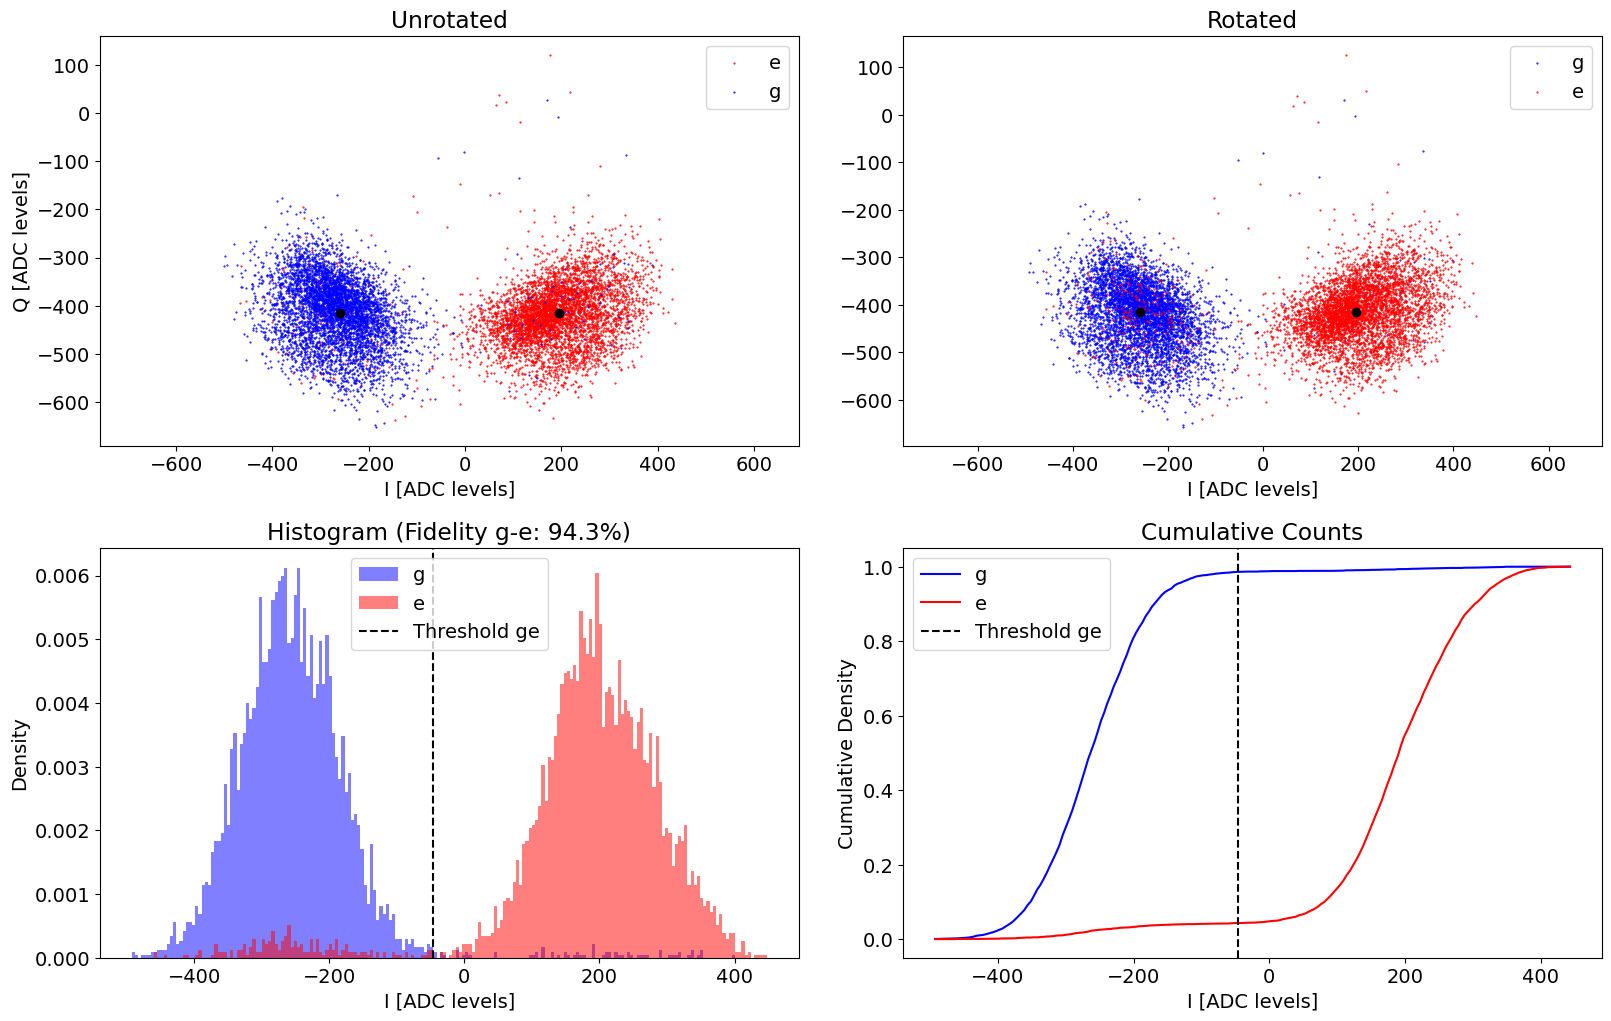

Plot saved to D:\experiments\260217_qsim_wigner_prac\plots\2026-03-16_18-42-09_histogram.png
Plot reference appended to D:\experiments\260217_qsim_wigner_prac\logs\2026-03-16.md
ge fidelity (%): 94.30000000000003
rotation angle (deg): 1.6006110805105107
threshold ge: -45.88090117115246


In [3]:
# Execute
# =================================
ss_runner = CharacterizationRunner(
    station = station,
    ExptClass = meas.HistogramExperiment,
    default_expt_cfg = singleshot_defaults,
    postprocessor = singleshot_postproc,
    job_client=client,
)

ss = ss_runner.execute(
    go_kwargs=dict(analyze=False, display=False),
    check_f=False,
    active_reset=False, # on recalibration of readout, turn off active reset because it will be wrong for selecting when to apply the qubit pulse
    relax_delay=2000,
    # active_reset=True,
    # relax_delay=200,
)
ss.display(station)

In [4]:
station.snapshot_hardware_config(update_main=False)
station.preview_config_update()

[CONFIG] Created new hardware_config version CFG-HW-20260316-00001
Comparing configurations:
Parent config file: D:\python\multimode_expts\configs\versions\hardware_config\CFG-HW-20260314-00018.yml
Key 'device.readout.phase' differs:
  Old value (config1): [9.856559754575812]
  New value (config2): [29.955267427781877]
Key 'device.readout.threshold' differs:
  Old value (config1): [-60.682403439264306]
  New value (config2): [-67.20146949892614]
Key 'device.readout.threshold_list' differs:
  Old value (config1): [[-60.682403439264306]]
  New value (config2): [[-67.20146949892614]]
Key 'device.readout.confusion_matrix_without_reset' differs:
  Old value (config1): [0.9855999999999998, 0.01440000000000019, 0.034399999999999986, 0.9656]
  New value (config2): [0.9856000000000004, 0.014399999999999635, 0.03759999999999997, 0.9624]
Key 'device.readout.Ie' differs:
  Old value (config1): [174.0642175937384]
  New value (config2): [182.68016054260679]
Key 'device.readout.Ig' differs:
  Old va

In [14]:
station.hardware_cfg.device.manipulate

{'f_ge': [4979.617487284074, 5157.8527963217475],
 'displace_sigma': [0.05, 0.05],
 'revival_time': [1.6139028785769014, 1.7366205852286094],
 'revival_stark_shift': [0.005102040816355523, -2.6792227141937364],
 'gain_to_alpha': [0.0002664034142894277, 0.00020045],
 'freq_to_alpha': [0.495062203431879, 0.0],
 'alpha_scale': [1.0147418910101649, 1.0],
 'chi_ge': [0.2802173281623599],
 'chi_ef': [1.2311804927283654],
 'ramp_sigma': 0.005,
 'revival_time_fast': [1.7378951097046815, 1.7378951097046815]}

## Photon Number Resolved  Spectroscopy

This is used to check that the fock states are well prepared before we do the tomography

In [5]:
photon_number_spectro_defaults = AttrDict(dict(
    start=3560, 
    step=0.1,
    expts=200,
    reps=2000,
    rounds=1,
    length=1,
    gain=400,
    sigma=0.1,
    qubits=[0],
    qubit=0,
    prepulse=False,
    pre_sweep_pulse=[],
    gate_based=False,
    relax_delay=250,
))

photon_number_spectro_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.single_qubit.pulse_probe_spectroscopy.PulseProbeSpectroscopyExperiment,
    default_expt_cfg=photon_number_spectro_defaults,
    job_client=client,
    use_queue=USE_QUEUE,
    # use_queue=False,
)

In [7]:
pre_sweep_pulse = mm_base_calib.prep_man_photon(man_no=1, photon_no=1)
pre_sweep_pulse = mm_base_calib.get_prepulse_creator(pre_sweep_pulse, station.hardware_cfg).pulse.tolist()
print(f"pre_sweep_pulse: {pre_sweep_pulse}")

pre_sweep_pulse: [[3563.149430155541, 3419.1760186165175, 1980.3362686592347], [9318, 8275, 8000], [0, 0, 0.5231449952479691], [0, 0, 0], [2, 2, 0], ['gauss', 'gauss', 'flat_top'], [0.035, 0.035, 0.005]]


In [12]:
span = 5
expt = 100
step = span / expt
start = station.hardware_cfg.device.qubit.f_ge[0] - span*0.5
length = 15
gain=30

# if tomo_expts_to_run['photon_number_spectro']:
photon_number_spectro = photon_number_spectro_runner.execute(
    go_kwargs=dict(analyze=True, display=True, save=True),
    pre_sweep_pulse=pre_sweep_pulse,
    prepulse=True,
    gate_based=False,
    start=start,
    length=length,
    sigma=1.,
    gain=gain,
    step=step,
    expts=expt,
    relax_delay=500,
    coupler_current=0.1e-3,
)

Job submitted: JOB-20260310-00024 (queue position: 1)

[0.2s] Job JOB-20260310-00024: pending

[2.2s] Job JOB-20260310-00024: running
[WORKER] Loading PulseProbeSpectroscopyExperiment from experiments.single_qubit.pulse_probe_spectroscopy
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260310-00024_PulseProbeSpectroscopyExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.1mA according to expt.cfg...
[WORKER] Done setting coupler current
 98%|███████████████████████████████▍| 196560/200000 [01:42<00:01, 1919.83it/s]
[111.3s] Job JOB-20260310-00024: completed
100%|████████████████████████████████| 200000/200000 [01:44<00:00, 1915.06it/s]
Saving D:\experiments\260217_qsim_wigner_prac\data\JOB-20260310-00024_PulseProbeSpectroscopyExperiment.h5
[WORKER] Saving expt object to: D:\experiments\260217_qsim_wigner_prac\expt_objs\JOB-20260310-00024_expt.pkl

Job completed! Data: D:\experiments\260217_qsim_wigner_prac\data\JOB-20260310-00024_Pu

Found peak in amps at [MHz] 3562.370226162439, HWHM 0.18280699008238063
Found peak in I at [MHz] 3562.372272851934, HWHM 0.16185549901118618
Found peak in Q at [MHz] 3561.8029147086595, HWHM -0.0037970516555358


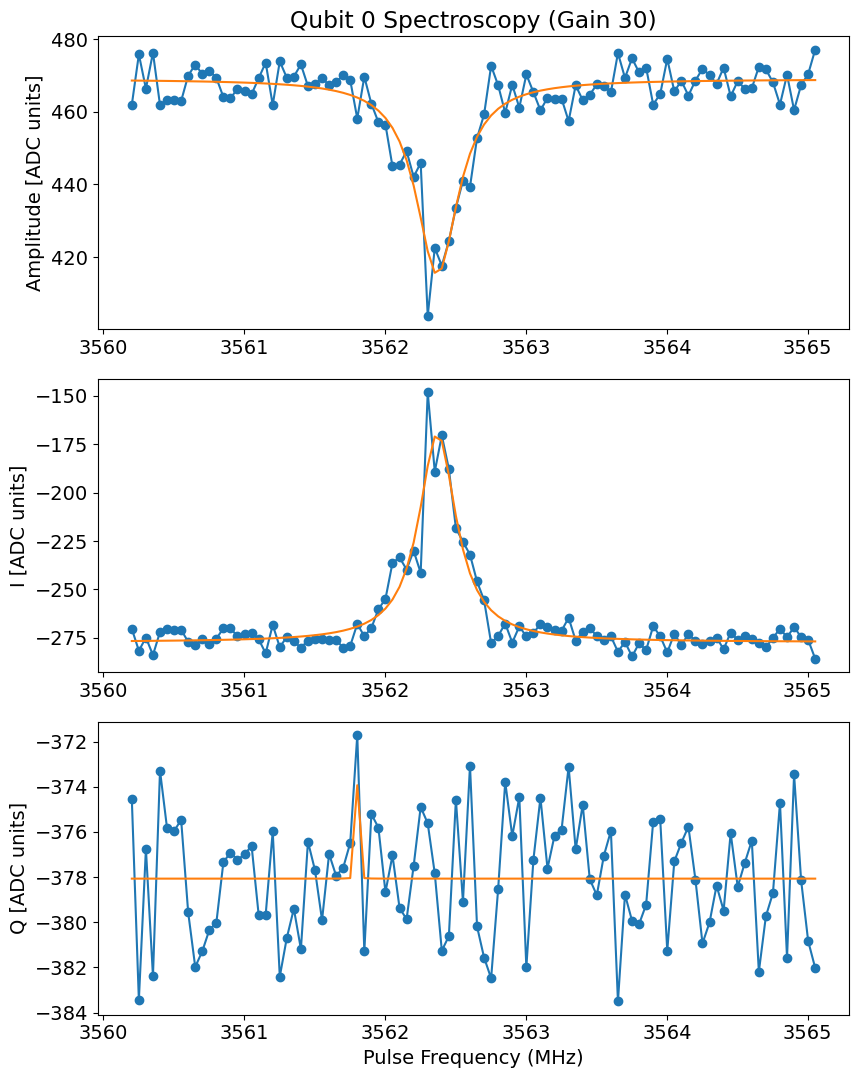

In [13]:
# if tomo_expts_to_run['photon_number_spectro']:
if USE_QUEUE:
    photon_number_spectro.display()

## Spectroscopy for f0g1

In [14]:
f0g1spec_defaults = AttrDict(dict(
    start=None,  # Will be computed in preprocessor from ds_storage
    step=0.2,
    expts=200,
    reps=100,
    rounds=1,
    length=1,
    gain=3000,
    pulse_type='gaussian',
    qubit_f=True,
    qubits=[0],
    prepulse=False,
    relax_delay=200,
))

def f0g1spec_preproc(station, default_expt_cfg, man_mode_no=1, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.man_mode_no = man_mode_no  # Store for postprocessor
    expt_cfg.update(kwargs)
    
    # Compute start frequency from dataset if not provided
    if expt_cfg.start is None:
        expt_cfg.start = station.ds_storage.get_freq('M' + str(man_mode_no)) - 20
    
    return expt_cfg

def f0g1spec_postproc(station, expt):
    man_mode_no = expt.cfg.expt.man_mode_no
    station.ds_storage.update_freq('M' + str(man_mode_no), expt.data['fit_avgi'][2])
    station.hardware_cfg.device.multiphoton['pi']['fn-gn+1']['frequency'][0] = expt.data['fit_avgi'][2]
    print(f"Updated man f0g1 freq to: {station.ds_storage.get_freq('M' + str(man_mode_no))}")
    station.snapshot_hardware_config(update_main=False)
    station.snapshot_man1_storage_swap(update_main=False)

Job submitted: JOB-20260310-00025 (queue position: 1)

[0.2s] Job JOB-20260310-00025: pending

[2.2s] Job JOB-20260310-00025: running
[WORKER] Loading PulseProbeF0g1SpectroscopyExperiment from experiments.single_qubit.pulse_probe_f0g1_spectroscopy
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260310-00025_PulseProbeF0g1SpectroscopyExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.1mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
100%|██████████████████████████████████| 20000/20000 [00:05<00:00, 3951.06it/s]
Saving D:\experiments\260217_qsim_wigner_prac\data\JOB-20260310-00025_PulseProbeF0g1SpectroscopyExperiment.h5
[WORKER] Saving expt object to: D:\experiments\260217_qsim_wigner_prac\expt_objs\JOB-20260310-00025_expt.pkl

[12.4s] Job JOB-20260310-00025: completed

Job completed! Data: D:\experiments\260217_qsim_wigner_prac\data\JOB-20260310-00025_PulseProbeF0g1SpectroscopyExperiment.h5
Updated man f0g1

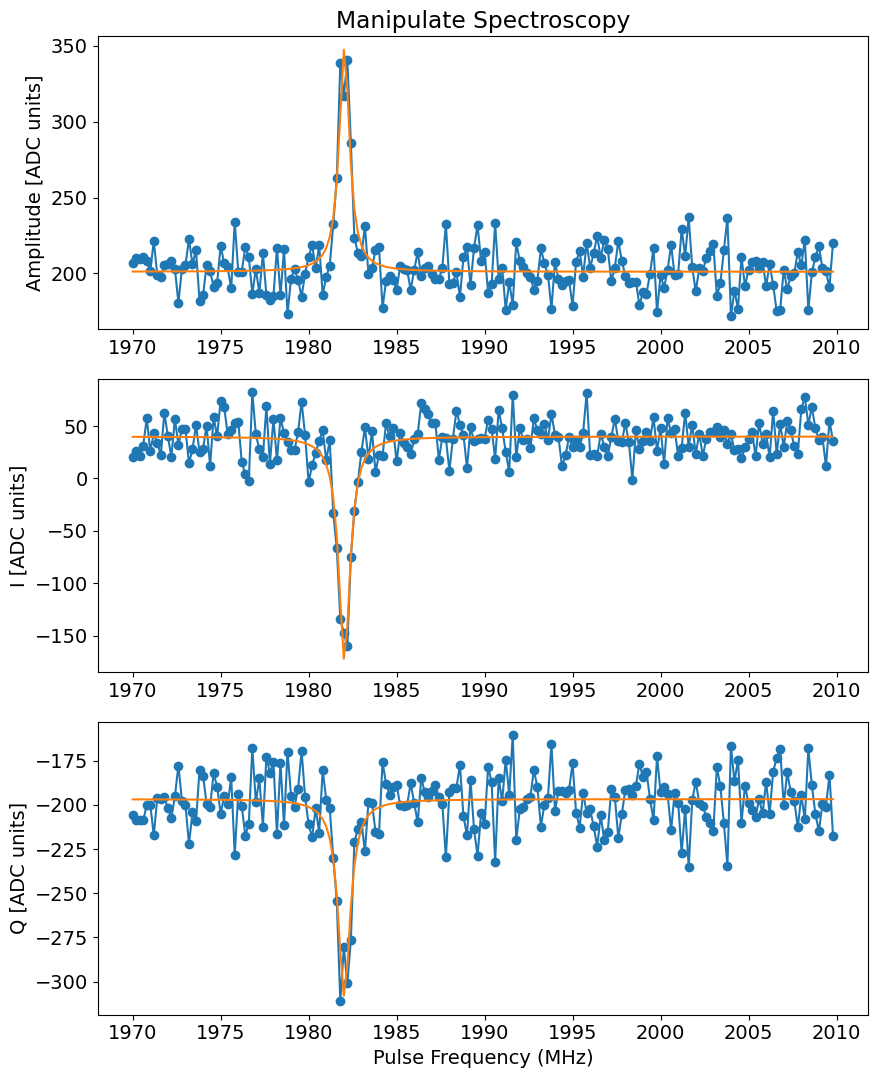

In [15]:
# Execute
# =================================
f0g1spec_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.PulseProbeF0g1SpectroscopyExperiment,
    default_expt_cfg=f0g1spec_defaults,
    preprocessor=f0g1spec_preproc,
    postprocessor=f0g1spec_postproc,
    job_client=client,
)

man_spec = f0g1spec_runner.execute(
    man_mode_no=1,
    start=1970,
    go_kwargs=dict(progress=True),
    relax_delay=250,
    # coupler_current=0.0,
)
man_spec.display()

## Parity Delay

In [10]:
parity_delay_defaults = AttrDict(dict(
    start=0.01,
    step=0.05,
    expts=50,
    reps=250,
    rounds=1,
    qubits=[0],
    parity_fast=False,
    normalize=False,
    active_reset=False,
    man_reset=True,
    gate_based=False,
    storage_reset=True,
    man_mode_no=1,
    relax_delay=2500, 
    param_to_calib='length', # length or ac_stark_shift 
    shift_sign=1, # 1 or -1 for ac stark shift direction
    ))


def parity_delay_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    if 'param_to_calib' in expt_cfg and expt_cfg.param_to_calib =='ac_stark_shift':
        expt_cfg.prepulse = False
        expt_cfg.pre_sweep_pulse = []
    elif 'param_to_calib' in expt_cfg and expt_cfg.param_to_calib =='length':
        expt_cfg.prepulse = True
        pre_sweep_pulse = mm_base_calib.prep_man_photon(man_no=expt_cfg.man_mode_no, photon_no=1)
        pre_sweep_pulse = mm_base_calib.get_prepulse_creator(pre_sweep_pulse, station.hardware_cfg).pulse.tolist()
        expt_cfg.pre_sweep_pulse = pre_sweep_pulse
    return expt_cfg

def parity_delay_postproc(station, expt):
    from fitting.fit_display_classes import LengthRabiFitting
    # Analyze the data
    length_rabi_analysis = LengthRabiFitting(expt.data, config = expt.cfg)
    for key in ['xpts', 'avgi', 'avgq']:
        if key in length_rabi_analysis.data:
            length_rabi_analysis.data[key] = np.array(length_rabi_analysis.data[key])
    length_rabi_analysis.analyze() #fitparams = [100, 0.1, 0, None, None, None])
    length_rabi_analysis.display(title_str='Length Rabi General F0g1')
    expt_cfg = expt.cfg.expt
    man_mode_no = expt_cfg.man_mode_no
    shift_sign = expt_cfg.shift_sign


    if expt_cfg.param_to_calib == 'length':
        delay = length_rabi_analysis.results['pi_length']
        print(f'Fitted revival time: {delay} us')
        old_delay = station.hardware_cfg.device.manipulate.revival_time[man_mode_no - 1]
        station.hardware_cfg.device.manipulate.revival_time[man_mode_no - 1] = delay
        print(f'Updated revival time for mode {man_mode_no}: {old_delay} -> {station.hardware_cfg.device.manipulate.revival_time[man_mode_no - 1]}')

    elif expt_cfg.param_to_calib == 'ac_stark_shift': 
        freq = length_rabi_analysis.data['fit_avgi'][1]
        print(f'Fitted ac Stark shift: {freq} MHz')
        old_freq = station.hardware_cfg.device.manipulate.revival_stark_shift[man_mode_no - 1]
        station.hardware_cfg.device.manipulate.revival_stark_shift[man_mode_no - 1] += shift_sign * freq
        print(f'Updated ac Stark shift for mode {man_mode_no}: {old_freq} -> {station.hardware_cfg.device.manipulate.revival_stark_shift[man_mode_no - 1]}')


### Calibrate first the AC stark shift

Manipulate in 0, qubit should not rotate

this is calibrating the virtual Z to correct from rotating frame to bare frame

Job submitted: JOB-20260316-00085 (queue position: 1)

[0.1s] Job JOB-20260316-00085: pending

[2.2s] Job JOB-20260316-00085: running
[WORKER] Loading ParityDelayExperiment from experiments.single_qubit.parity_delay
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260316-00085_ParityDelayExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.5mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 97%|███████████████████████████████████████▊ | 97/100 [00:35<00:01,  2.79it/s]
[44.4s] Job JOB-20260316-00085: completed
100%|████████████████████████████████████████| 100/100 [00:36<00:00,  2.76it/s]
Saving D:\experiments\260217_qsim_wigner_prac\data\JOB-20260316-00085_ParityDelayExperiment.h5
[WORKER] Saving expt object to: D:\experiments\260217_qsim_wigner_prac\expt_objs\JOB-20260316-00085_expt.pkl

Job completed! Data: D:\experiments\260217_qsim_wigner_prac\data\JOB-20260316-00085_ParityDelayExperiment.h5
p1: 0.29499158

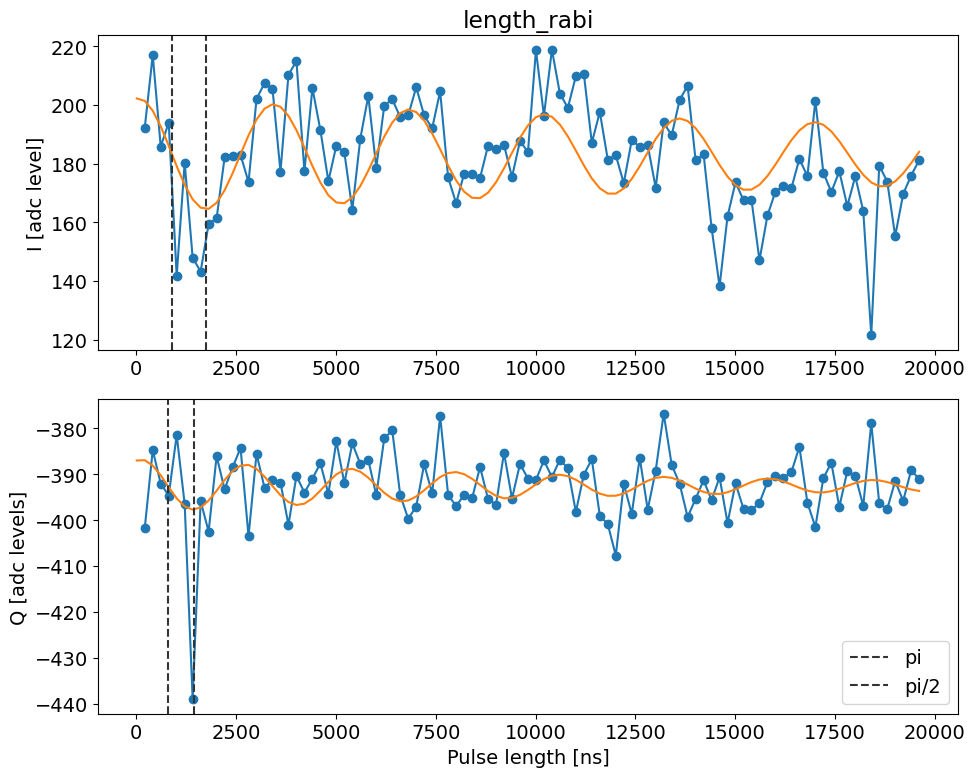

Fitted ac Stark shift: 0.29499158981531903 MHz
Updated ac Stark shift for mode 1: 0.005102040816355523 -> 0.30009363063167455


In [11]:
parity_delay_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.ParityDelayExperiment,
    default_expt_cfg=parity_delay_defaults,
    postprocessor=parity_delay_postproc,
    preprocessor=parity_delay_preproc,
    job_client=client,
    use_queue=USE_QUEUE,
)

parity_delay_ac_stark = parity_delay_runner.execute(
    param_to_calib='ac_stark_shift', 
    go_kwargs=dict(analyze=False, display=False),
    step=0.2,
    expts=100,
    reps=100,
    shift_sign=+1,
    # coupler_current=0.0,
)

Confirming the correction is in the right direction

In [12]:
parity_delay_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.ParityDelayExperiment,
    default_expt_cfg=parity_delay_defaults,
    preprocessor=parity_delay_preproc,
    job_client=client,
    use_queue=USE_QUEUE,
)

parity_delay_ac_stark = parity_delay_runner.execute(
    param_to_calib='ac_stark_shift', 
    go_kwargs=dict(analyze=False, display=False),
    step=0.2,
    expts=100,
    reps=100,
    # coupler_current=0.0,
)

Job submitted: JOB-20260316-00086 (queue position: 1)

[0.1s] Job JOB-20260316-00086: pending

[2.1s] Job JOB-20260316-00086: running
[WORKER] Loading ParityDelayExperiment from experiments.single_qubit.parity_delay
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260316-00086_ParityDelayExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.5mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 93%|██████████████████████████████████████▏  | 93/100 [00:34<00:02,  2.80it/s]
[42.4s] Job JOB-20260316-00086: completed
100%|████████████████████████████████████████| 100/100 [00:36<00:00,  2.74it/s]
D:\python\multimode_expts\fitting\fitting.py:67: OptimizeWarning: Covariance of the parameters could not be estimated
  pOpt, pCov = sp.optimize.curve_fit(expfunc, xdata, ydata, p0=fitparams, maxfev=200000)
D:\python\multimode_expts\fitting\fitting.py:56: RuntimeWarning: overflow encountered in exp
  return y0 + yscale*np.exp(

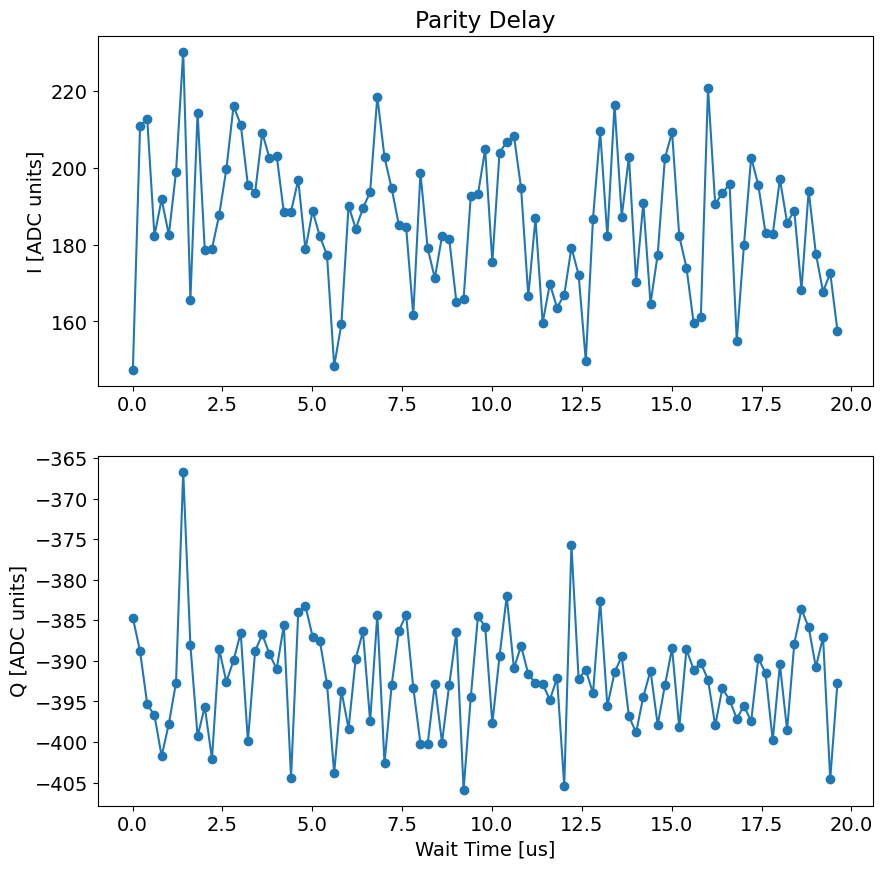

In [13]:
parity_delay_ac_stark.display(fit=False)

### Now parity length after the AC stark shift is calibrated

Job submitted: JOB-20260316-00087 (queue position: 1)

[0.1s] Job JOB-20260316-00087: pending

[2.1s] Job JOB-20260316-00087: running
[WORKER] Loading ParityDelayExperiment from experiments.single_qubit.parity_delay
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260316-00087_ParityDelayExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.5mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 93%|██████████████████████████████████████▏  | 93/100 [00:35<00:02,  2.67it/s]
[44.4s] Job JOB-20260316-00087: completed
100%|████████████████████████████████████████| 100/100 [00:37<00:00,  2.64it/s]
Saving D:\experiments\260217_qsim_wigner_prac\data\JOB-20260316-00087_ParityDelayExperiment.h5
[WORKER] Saving expt object to: D:\experiments\260217_qsim_wigner_prac\expt_objs\JOB-20260316-00087_expt.pkl

Job completed! Data: D:\experiments\260217_qsim_wigner_prac\data\JOB-20260316-00087_ParityDelayExperiment.h5
p1: 0.27920745

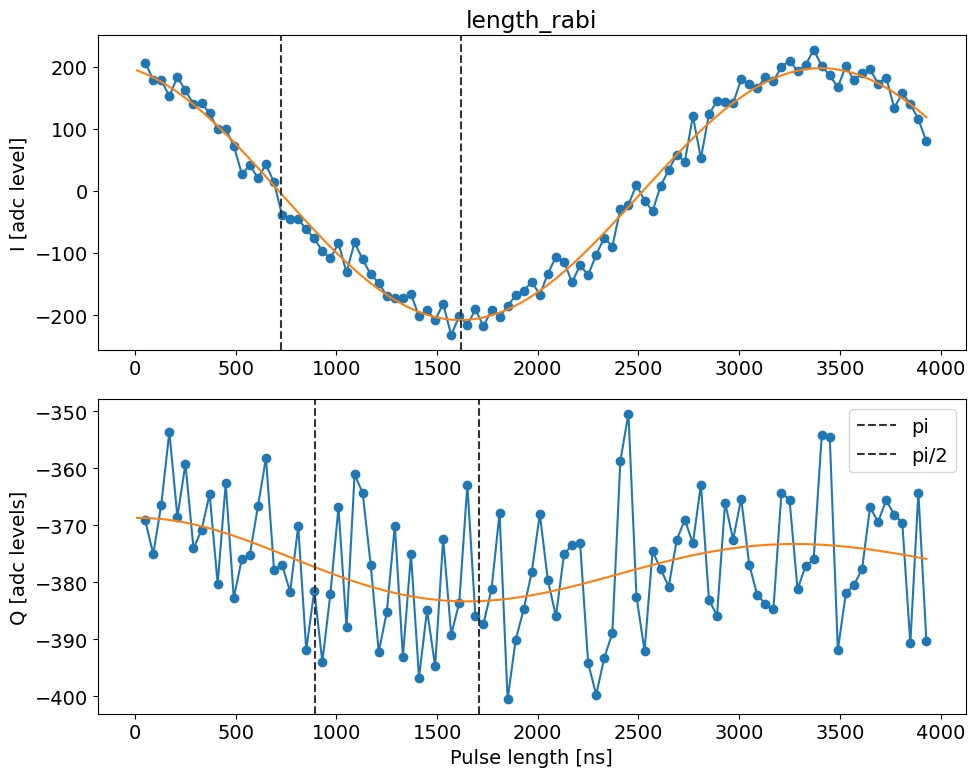

Fitted revival time: 1.617664734427571 us
Updated revival time for mode 1: 1.3590037534300656 -> 1.617664734427571


In [14]:
parity_delay_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.ParityDelayExperiment,
    default_expt_cfg=parity_delay_defaults,
    postprocessor=parity_delay_postproc,
    preprocessor=parity_delay_preproc,
    job_client=client,
    use_queue=USE_QUEUE,
)

parity_delay_ac_stark = parity_delay_runner.execute(
    param_to_calib='length', 
    parity_fast=False,
    go_kwargs=dict(analyze=False, display=False),
    step=0.04,
    expts=100,
    reps=100,
    # coupler_current=0.0,
)

In [15]:
station.update_all_station_snapshots(update_main=False)

[CONFIG] Created new hardware_config version CFG-HW-20260316-00032
[CONFIG] Reusing existing multiphoton_config version CFG-MP-20260121-00001
[CONFIG] Reusing existing man1_storage_swap version CFG-M1-20260316-00008
[CONFIG] Reusing existing floquet_storage_swap version CFG-FL-20260223-00017
Config snapshots for current station:
  hardware_config: CFG-HW-20260316-00032
  multiphoton_config: CFG-MP-20260121-00001
  man1_storage_swap: CFG-M1-20260316-00008
  floquet_storage_swap: CFG-FL-20260223-00017


{'hardware_config': 'CFG-HW-20260316-00032',
 'multiphoton_config': 'CFG-MP-20260121-00001',
 'man1_storage_swap': 'CFG-M1-20260316-00008',
 'floquet_storage_swap': 'CFG-FL-20260223-00017'}

## Manipulate Parity Spectroscopy

In [6]:
station.hardware_cfg.device.manipulate

{'f_ge': [4997.686201414042, 5157.8527963217475],
 'displace_sigma': [0.05, 0.05],
 'revival_time': [1.349329728251551],
 'revival_stark_shift': [0.005102040816355523, -2.6792227141937364],
 'gain_to_alpha': [0.00031210237952875226, 0.00020045],
 'freq_to_alpha': [0.495062203431879, 0.0],
 'alpha_scale': [0.946793635334806, 1.0],
 'chi_ge': [0.2802173281623599],
 'chi_ef': [1.2311804927283654],
 'ramp_sigma': 0.005,
 'revival_time_fast': [1.7378951097046815, 1.7378951097046815]}

In [17]:
parity_freq_defaults = AttrDict(dict(
    start=4960,
    stop=5020,
    step=0.60,
    reps=200,
    rounds=1,
    qubits=[0],
    normalize=False,
    single_shot=False,
    singleshot_reps=10000,
    span=20,
    man_mode_no=1,
    displace=(True, 0.1, 1000),
    const_pulse=(False, 1),
    f0g1_cavity=0,
    prepulse=False,
    pre_sweep_pulse=None,
    relax_delay=2500,
))

def parity_freq_postproc(station, expt):
    from fitting.fit_display_classes import Spectroscopy
    spec = Spectroscopy(expt.data, config=expt.cfg)
    spec.analyze()
    spec.display(title='Parity Frequency Experiment')

    expt_cfg = expt.cfg.expt
    man_mode_no = expt_cfg.man_mode_no
    fitted_freq = spec.data['fit_avgi'][2]
    old_freq = station.hardware_cfg.device.manipulate.f_ge[man_mode_no - 1]
    station.hardware_cfg.device.manipulate.f_ge[man_mode_no - 1] = fitted_freq
    print(f'Updated manipulate f_ge for mode {man_mode_no} from {old_freq} to {fitted_freq}')


parity_freq_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.ParityFreqExperiment,
    default_expt_cfg=parity_freq_defaults,
    postprocessor=parity_freq_postproc,
    job_client=client,
    use_queue=USE_QUEUE,
)


Job submitted: JOB-20260316-00088 (queue position: 1)

[0.2s] Job JOB-20260316-00088: pending

[2.2s] Job JOB-20260316-00088: running
[WORKER] Loading ParityFreqExperiment from experiments.single_qubit.parity_freq
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260316-00088_ParityFreqExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.5mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 96%|███████████████████████████████████████▎ | 96/100 [00:37<00:01,  2.25it/s]
[46.5s] Job JOB-20260316-00088: completed
100%|████████████████████████████████████████| 100/100 [00:38<00:00,  2.57it/s]
Saving D:\experiments\260217_qsim_wigner_prac\data\JOB-20260316-00088_ParityFreqExperiment.h5
[WORKER] Saving expt object to: D:\experiments\260217_qsim_wigner_prac\expt_objs\JOB-20260316-00088_expt.pkl

Job completed! Data: D:\experiments\260217_qsim_wigner_prac\data\JOB-20260316-00088_ParityFreqExperiment.h5
Found peak in amps 

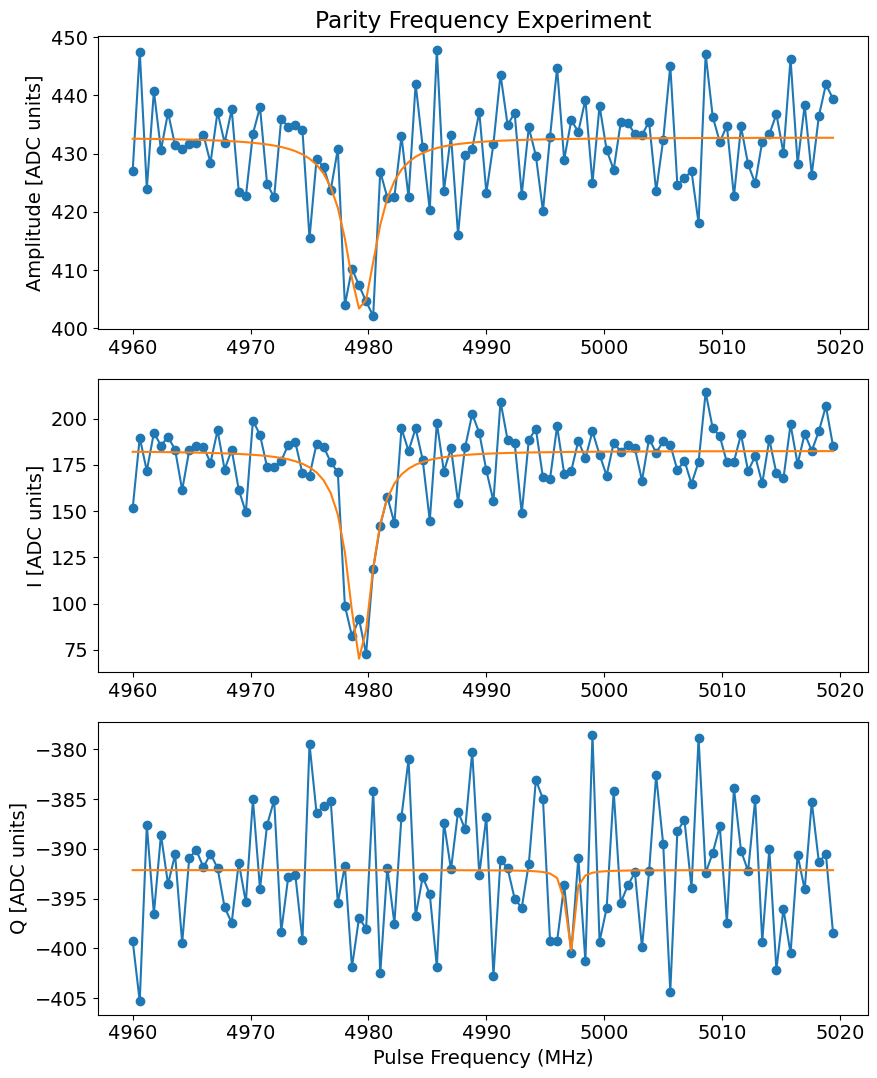

Updated manipulate f_ge for mode 1 from 4997.686201414042 to 4979.290774274023


In [18]:
parity_freq = parity_freq_runner.execute(
    go_kwargs=dict(analyze=False, display=False),
    reps=100,
    # coupler_current = 0e-3,
)

In [19]:
station.update_all_station_snapshots(update_main=False)

[CONFIG] Created new hardware_config version CFG-HW-20260316-00033
[CONFIG] Reusing existing multiphoton_config version CFG-MP-20260121-00001
[CONFIG] Reusing existing man1_storage_swap version CFG-M1-20260316-00008
[CONFIG] Reusing existing floquet_storage_swap version CFG-FL-20260223-00017
Config snapshots for current station:
  hardware_config: CFG-HW-20260316-00033
  multiphoton_config: CFG-MP-20260121-00001
  man1_storage_swap: CFG-M1-20260316-00008
  floquet_storage_swap: CFG-FL-20260223-00017


{'hardware_config': 'CFG-HW-20260316-00033',
 'multiphoton_config': 'CFG-MP-20260121-00001',
 'man1_storage_swap': 'CFG-M1-20260316-00008',
 'floquet_storage_swap': 'CFG-FL-20260223-00017'}

In [9]:
station.snapshot_hardware_config(update_main=False)

[CONFIG] Created new hardware_config version CFG-HW-20260211-00050


'CFG-HW-20260211-00050'

## Manipulate Ramsey (to finetune frequency)
- This will use displace pulse instead do qubit pi/2 to calibrate; we want fine calibration of manipulate frequency not some fast way of extracting T2 time or finding stark shift on f0g1 transition
- Make sure displacements are small $(\alpha \approx 0.2)$
- Somehow i don't get full contrast, like the lowst i,q value dont correspond to g 




In [29]:
cavity_ramsey_defaults = AttrDict(dict(
    start=0.01,           # start delay
    step=0.05,            # step size
    expts=200,            # number of experiments
    ramsey_freq=3.7,      # Ramsey frequency
    reps=100,              # repetitions
    rounds=1,             # rounds
    qubits=[0],           # qubits
    checkEF=False,        # check EF
    f0g1_cavity=0,        # f0g1 cavity
    init_gf=False,        # initialize gf
    active_reset=False,   # active reset
    man_reset=True,       # manipulate reset
    storage_reset=True,   # storage reset
    user_defined_pulse=None, # [on/off, freq, gain, sigma (mus), 0, 4] # if off, use config freq
    parity_meas=True,     # parity measurement
    man_mode_no=1,
    storage_ramsey=[False, 2, True], # storage Ramsey
    man_ramsey=None,      # manipulate Ramsey
    coupler_ramsey=False, # coupler Ramsey
    custom_coupler_pulse=None, # custom coupler pulse
    echoes=[False, 0],    # echoes
    prepulse=False,       # prepulse
    postpulse=False,      # postpulse
    gate_based=False,     # gate based
    pre_sweep_pulse=None, # pre sweep pulse
    post_sweep_pulse=None,# post sweep pulse
    prep_e_first = True,
    relax_delay=2500      # relax delay
))

def cavity_ramsey_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)

    expt_cfg.man_idx = expt_cfg.man_mode_no - 1

    if expt_cfg.user_defined_pulse is None:
        expt_cfg.user_defined_pulse = [True, station.hardware_cfg.device.manipulate.f_ge[expt_cfg.man_mode_no-1], 10, station.hardware_cfg.device.manipulate.displace_sigma[expt_cfg.man_mode_no-1], 0, 4]

    if expt_cfg.man_ramsey is None:
        expt_cfg.man_ramsey = [False, expt_cfg.man_mode_no -1]
    if expt_cfg.custom_coupler_pulse is None:
        expt_cfg.custom_coupler_pulse = [[944.25], [1000], [0.316677658], [0], [1], ['flat_top'], [0.005]]
    if expt_cfg.pre_sweep_pulse is None:
        expt_cfg.pre_sweep_pulse = []
    if expt_cfg.post_sweep_pulse is None:
        expt_cfg.post_sweep_pulse = []
    # do we need to set the relax delay here?
    return expt_cfg

def cavity_ramsey_postproc(station, expt):

    from fitting.fit_display_classes import RamseyFitting
    ramsey_analysis = RamseyFitting(expt.data, config=expt.cfg)
    delta_f = min(ramsey_analysis.data['f_adjust_ramsey_avgi'])

    expt_cfg = expt.cfg.expt
    man_mode_no = expt_cfg.man_mode_no
    old_freq = station.hardware_cfg.device.manipulate.f_ge[man_mode_no - 1]
    station.hardware_cfg.device.manipulate.f_ge[man_mode_no - 1] = old_freq + delta_f
    print(f'Updated manipulate f_ge for mode {man_mode_no} from {old_freq} to {station.hardware_cfg.device.manipulate.f_ge[man_mode_no - 1]}')

cavity_ramsey_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.single_qubit.t2_cavity.CavityRamseyExperiment,
    default_expt_cfg=cavity_ramsey_defaults,
    preprocessor=cavity_ramsey_preproc,
    postprocessor=cavity_ramsey_postproc,
    job_client=client,
    # user=user,    
    use_queue=USE_QUEUE,
)

In [30]:
# station.hardware_cfg.device.manipulate.f_ge[0]=4979.614305651117

cavity_ramsey = cavity_ramsey_runner.execute(
    ramsey_freq=0.5,
    step = 0.1,
    expts = 100,
    reps = 200,
    prep_e_first = False,
    user_defined_pulse=[True, station.hardware_cfg.device.manipulate.f_ge[0], 2000, 
                                station.hardware_cfg.device.manipulate.displace_sigma[0],
                                  0, 4],
    # coupler_current = 0e-3,
)

Job submitted: JOB-20260307-00043 (queue position: 1)

[0.2s] Job JOB-20260307-00043: pending

[2.2s] Job JOB-20260307-00043: running
[WORKER] Loading CavityRamseyExperiment from experiments.single_qubit.t2_cavity
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260307-00043_CavityRamseyExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.1mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
100
 90%|███████████████████████████████▌   | 18018/20000 [00:45<00:04, 396.90it/s]
[58.5s] Job JOB-20260307-00043: completed
100%|███████████████████████████████████| 20000/20000 [00:50<00:00, 397.10it/s]
No echoes in the data
Saving D:\experiments\260217_qsim_wigner_prac\data\JOB-20260307-00043_CavityRamseyExperiment.h5
[WORKER] Saving expt object to: D:\experiments\260217_qsim_wigner_prac\expt_objs\JOB-20260307-00043_expt.pkl

Job completed! Data: D:\experiments\260217_qsim_wigner_prac\data\JOB-20260307-00043_CavityRamseyE

Using user defined frequency: 4997.686201414042 MHz
Current pi pulse frequency: 4997.686201414042
Fit frequency from I [MHz]: 0.5009053754462456 +/- 0.00155446245143896
Suggested new pi pulse frequency from fit I [MHz]:
 	4997.685296038596
 	4998.687106789489
T2 Ramsey from fit I [us]: 29166688.575829275
Fit frequency from Q [MHz]: 4.999352391565499 +/- 35.89861131715204
Suggested new pi pulse frequencies from fit Q [MHz]:
 	4993.186849022477
 	5003.185553805608
T2 Ramsey from fit Q [us]: 0.9900000000000002


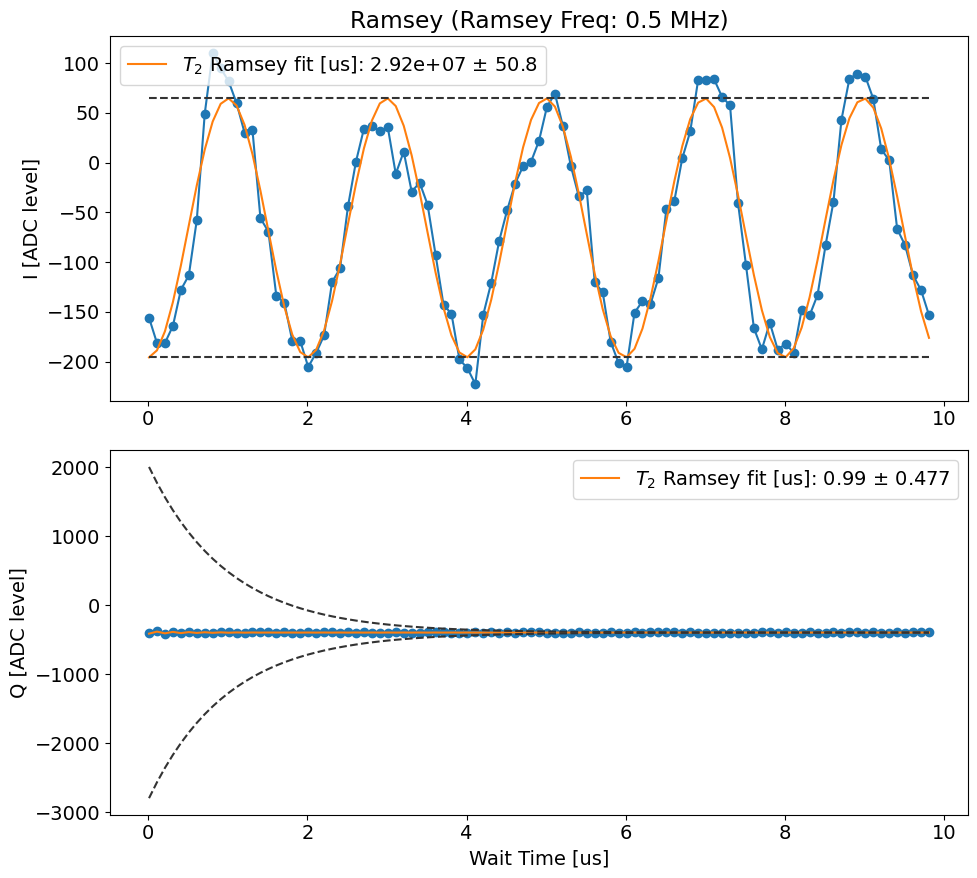

In [31]:
if USE_QUEUE:
    cavity_ramsey.display()

## Gain to alpha calibration

will do tomography on the vacuum state

$$
W_\alpha(\ket{0} \bra{0}) = \frac 2\pi e^{-2|\alpha|^2}
$$

In [32]:
do_parity_gain_defaults = AttrDict(dict(
    start=0,
    step=100,
    expts=40,
    reps=250,
    rounds=1,
    qubit=0,
    qubits=[0],
    normalize=False,
    single_shot=False,
    singleshot_reps=1000,
    singleshot_active_reset=False,
    singleshot_man_reset=True,
    singleshot_storage_reset=True,
    active_reset=False,
    man_reset=True,
    storage_reset=True,
    span=1000,
    prep_e=False,
    manipulate=1,
    displace=(True, 0.05), # [enable, sigma] (gaussian length is 4sigma)
    const_pulse=(False, 1), # [enable, length]
    f0g1_cavity=0,
    prepulse=False,
    pre_sweep_pulse=None,
    relax_delay=2500, 
    pulse_correction=False,
    parity_fast=True,
    scaling_amplitude=True,
    plot_IQ=True,
    man_mode_no=1,
))


def parity_gain_postproc(station, expt):
    expt_cfg = expt.cfg.expt
    scaling_amplitude = expt_cfg.scaling_amplitude
    man_mode_no = expt_cfg.man_mode_no
    if expt_cfg.plot_IQ:
        i_data = expt.data['idata']
        q_data = expt.data['qdata']
        fig, ax = plt.subplots(1,1, figsize=(6,6))
        ax.scatter(i_data, q_data, s=1, alpha=0.5)
        ax.set_xlabel('I')
        ax.set_ylabel('Q')
        ax.set_title('IQ Scatter Plot')
        plt.show()
    gain_to_alpha = expt.data['gain_to_alpha']
    old_gain_to_alpha = station.hardware_cfg.device.manipulate.gain_to_alpha[expt_cfg.man_mode_no - 1]
    print(f'Gain to alpha for mode {expt_cfg.man_mode_no} : {old_gain_to_alpha} -> {gain_to_alpha}')
    station.hardware_cfg.device.manipulate.gain_to_alpha[man_mode_no - 1] = gain_to_alpha
    if scaling_amplitude:
        scale = expt.data['scale']
        old_scale = station.hardware_cfg.device.manipulate.alpha_scale[man_mode_no - 1]
        station.hardware_cfg.device.manipulate.alpha_scale[man_mode_no - 1] = scale
        print(f'Scaling amplitude for mode {man_mode_no} : {old_scale} -> {scale}')

In [33]:
parity_gain_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.single_qubit.parity_gain.ParityGainExperiment,
    default_expt_cfg=do_parity_gain_defaults,
    postprocessor=parity_gain_postproc,
    job_client=client,
    use_queue=USE_QUEUE,
)


Job submitted: JOB-20260313-00097 (queue position: 1)

[0.1s] Job JOB-20260313-00097: pending

[2.2s] Job JOB-20260313-00097: running
[WORKER] Loading ParityGainExperiment from experiments.single_qubit.parity_gain
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260313-00097_ParityGainExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.1mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
4997.686201414042
Updating gain register 100
100%|███████████████████████████████████| 12000/12000 [00:30<00:00, 399.27it/s]
4997.686201414042
Updating gain register 100
 82%|█████████████████████████████▍      | 9828/12000 [00:24<00:05, 399.33it/s]
[66.5s] Job JOB-20260313-00097: completed
100%|███████████████████████████████████| 12000/12000 [00:30<00:00, 399.32it/s]
plot: False
Gain to Alpha Conversion Factor: 0.0002976719165099735
alpha = 1 requires gain of : 3359.40323738
Saving D:\experiments\260217_qsim_wigner_prac\data\

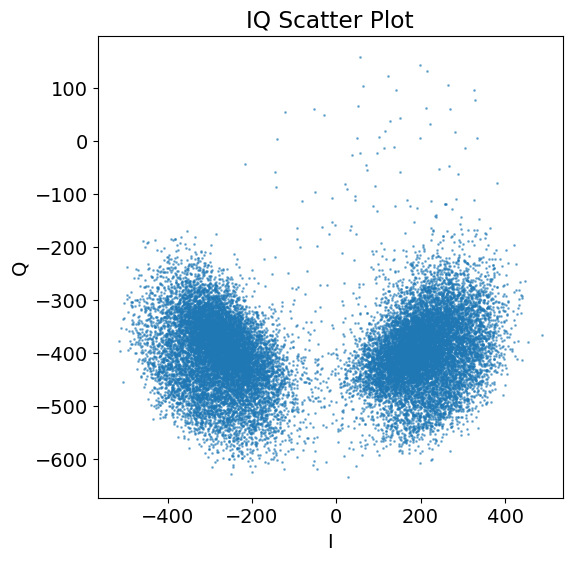

Gain to alpha for mode 1 : 0.00031210237952875226 -> 0.0002976719165099735
Scaling amplitude for mode 1 : 0.946793635334806 -> 0.8901122176575439


In [34]:

parity_gain_expt = parity_gain_runner.execute(
    pulse_correction=True, 
    # if number of photons in man is large, pi/2 pulses are bad. 
    # therefore, if pulse_correction = True: 
    # do a second set of parity measurements using pi/2, wait, -pi/2 
    # and take the contrast between this measurement and 
    # the standard pi/2, wait, pi/2 parity measurement.
    reps=300,
    step=100,
    parity_fast=False,
    go_kwargs=dict(analyze=False, display=False),
    # active_reset=True, # 500uA
    # man_reset=True,# 500uA
    # pre_selection_reset=False,
    # relax_delay=1500,
    )


plot: True
Gain to Alpha Conversion Factor: 0.00032278691388261735


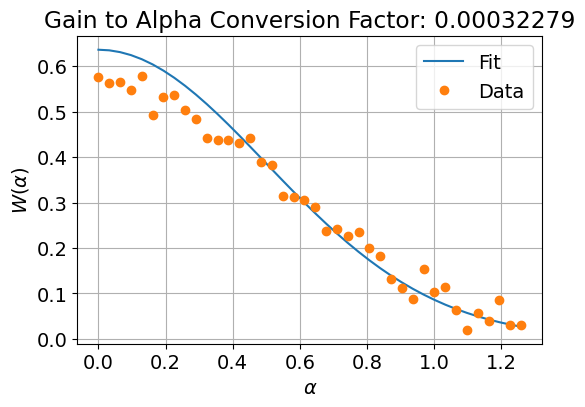

alpha = 1 requires gain of : 3098.01902429


In [35]:
if USE_QUEUE: 
    parity_gain_expt.analyze(scale=False, plot=True)

In [41]:
station.hardware_cfg.device.manipulate.alpha_scale[0]

1.0

In [37]:
station.hardware_cfg.device.manipulate.gain_to_alpha[0] = parity_gain_expt.data['gain_to_alpha']
station.hardware_cfg.device.manipulate.alpha_scale[0] = parity_gain_expt.data['scale']

In [42]:
station.snapshot_hardware_config(update_main=False)

[CONFIG] Created new hardware_config version CFG-HW-20260313-00014


'CFG-HW-20260313-00014'

## Cavity ramsey vs gain for Kerr

In [19]:
kerr_ramsey_defaults = AttrDict(dict(
    start=0.01,           # start delay
    step=0.02,            # step size
    expts=100,            # number of experiments
    ramsey_freq=3.7,      # Ramsey frequency
    kerr_gain=2000,
    kerr_detune=-10,
    reps=100,              # repetitions
    rounds=1,             # rounds
    qubits=[0],           # qubits
    checkEF=False,        # check EF
    f0g1_cavity=0,        # f0g1 cavity
    init_gf=False,        # initialize gf
    active_reset=False,   # active reset
    man_reset=True,       # manipulate reset
    storage_reset=True,   # storage reset
    user_defined_pulse=None, # [on/off, freq, gain, sigma (mus), 0, 4] # if off, use config freq
    parity_meas=True,     # parity measurement
    man_mode_no=1,
    storage_ramsey=[False, 2, True], # storage Ramsey
    man_ramsey=None,      # manipulate Ramsey
    coupler_ramsey=False, # coupler Ramsey
    custom_coupler_pulse=None, # custom coupler pulse
    echoes=[False, 0],    # echoes
    prepulse=False,       # prepulse
    postpulse=False,      # postpulse
    gate_based=False,     # gate based
    pre_sweep_pulse=None, # pre sweep pulse
    post_sweep_pulse=None,# post sweep pulse
    prep_e_first=True,
    normalize=False,
    swept_params=['displace_gain', 'kerr_detune'],
    kerr_detunes = np.linspace(-100, 100, 5).tolist(),
    displace_gains = np.arange(2000, 8001, 1000).tolist(),
    kerr_drive_type='man-qubit', # 'man-coupler', 'qubit'
    relax_delay=2500,
))

def kerr_ramsey_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)

    man_mode_no = expt_cfg.man_mode_no
    hw = station.hardware_cfg

    if expt_cfg.user_defined_pulse is None:
        expt_cfg.user_defined_pulse = [
            True,
            hw.device.manipulate.f_ge[man_mode_no - 1], # freq
            2000,  # will be overridden if expt_cfg.displace_gain is set! # gain
            hw.device.manipulate.displace_sigma[man_mode_no - 1], # sigma
            0, # length
            4, # proxy for ch for displacement, 4 = man
        ]
    
    # [on/off, freq, gain, sigma (mus), length, channel]
    if expt_cfg.man_ramsey is None:
        expt_cfg.man_ramsey = [False, man_mode_no - 1]
    if expt_cfg.custom_coupler_pulse is None and expt_cfg.kerr_drive_type == 'man-coupler':
        expt_cfg.custom_coupler_pulse = [[944.25], [1000], [0.316677658], [0], [1], ['flat_top'], [0.005]]
    if expt_cfg.pre_sweep_pulse is None:
        expt_cfg.pre_sweep_pulse = []
    if expt_cfg.post_sweep_pulse is None:
        expt_cfg.post_sweep_pulse = []

    print(expt_cfg)
    return expt_cfg

# def kerr_ramsey_postproc(station, expt):
#     pass

In [17]:
kerr_lengths = np.linspace(0.010, 1, 11).tolist()
displace_gains = np.arange(500, 1001, 500).tolist()
kerr_lengths

[0.01,
 0.109,
 0.20800000000000002,
 0.30700000000000005,
 0.406,
 0.505,
 0.6040000000000001,
 0.7030000000000001,
 0.802,
 0.901,
 1.0]

In [ ]:
kerr_ramsey_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.KerrCavityRamseyExperiment,
    # ExptProgram=meas.qsim.kerr.KerrCavityRamseyProgram,
    ExptProgram=meas.qsim.sideband_scramble.StorageT1Program,
    default_expt_cfg=kerr_ramsey_defaults,
    preprocessor=kerr_ramsey_preproc,
    # postprocessor=kerr_ramsey_postproc,
    job_client=client,
)

kerr_lengths = np.linspace(0.010, 1, 11).tolist()
displace_gains = np.arange(500, 1001, 500).tolist()

kerr_ramsey = kerr_ramsey_runner.execute(
    ramsey_freq=4,
    kerr_gain=0, # gain for kerr pulse
    kerr_detune=0,
    reps=50,
    prep_e_first=False,
    active_reset=False,
    # man_reset=True,
    swept_params = ['displace_gain', 'kerr_length'],
    kerr_lengths = kerr_lengths,
    displace_gains = displace_gains,
    # displace_gain = 5000,
    kerr_drive_type='man-qubit', # 'man-coupler', 'qubit
    init_man_fock_state = '+',
)
kerr_ramsey.display()

{'start': 0.01, 'step': 0.02, 'expts': 100, 'ramsey_freq': 4, 'kerr_gain': 0, 'kerr_detune': 0, 'reps': 50, 'rounds': 1, 'qubits': [0], 'checkEF': False, 'f0g1_cavity': 0, 'init_gf': False, 'active_reset': False, 'man_reset': True, 'storage_reset': True, 'user_defined_pulse': [True, 4997.686201414042, 2000, 0.05, 0, 4], 'parity_meas': True, 'man_mode_no': 1, 'storage_ramsey': [False, 2, True], 'man_ramsey': [False, 0], 'coupler_ramsey': False, 'custom_coupler_pulse': None, 'echoes': [False, 0], 'prepulse': False, 'postpulse': False, 'gate_based': False, 'pre_sweep_pulse': [], 'post_sweep_pulse': [], 'prep_e_first': False, 'normalize': False, 'swept_params': ['displace_gain', 'kerr_length'], 'kerr_detunes': [-100.0, -50.0, 0.0, 50.0, 100.0], 'displace_gains': [500, 1000], 'kerr_drive_type': 'man-qubit', 'relax_delay': 2500, 'kerr_lengths': [0.01, 0.109, 0.20800000000000002, 0.30700000000000005, 0.406, 0.505, 0.6040000000000001, 0.7030000000000001, 0.802, 0.901, 1.0], 'init_man_fock_stat

RuntimeError: Job JOB-20260224-00427 failed: AttributeError: 'AttrDict' object has no attribute 'ro_stor'
Traceback (most recent call last):
  File "D:\python\multimode_expts\job_server\worker.py", line 366, in _execute_job
    data_file_path, expt_pickle_path = self._run_experiment(ExptClass, expt_config, job)
                                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\python\multimode_expts\job_server\worker.py", line 552, in _run_experiment
    expt.go(
  File "D:\python\multimode_expts\slab\experiment.py", line 166, in go
    data=self.acquire(progress)
         ^^^^^^^^^^^^^^^^^^^^^^
  File "D:\python\multimode_expts\experiments\qsim\qsim_base.py", line 344, in acquire
    self.prog = self.ProgramClass(soccfg=self.soccfg, cfg=self.cfg)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\python\multimode_expts\experiments\qsim\qsim_base.py", line 32, in __init__
    super().__init__(soccfg, cfg)
  File "D:\python\mu

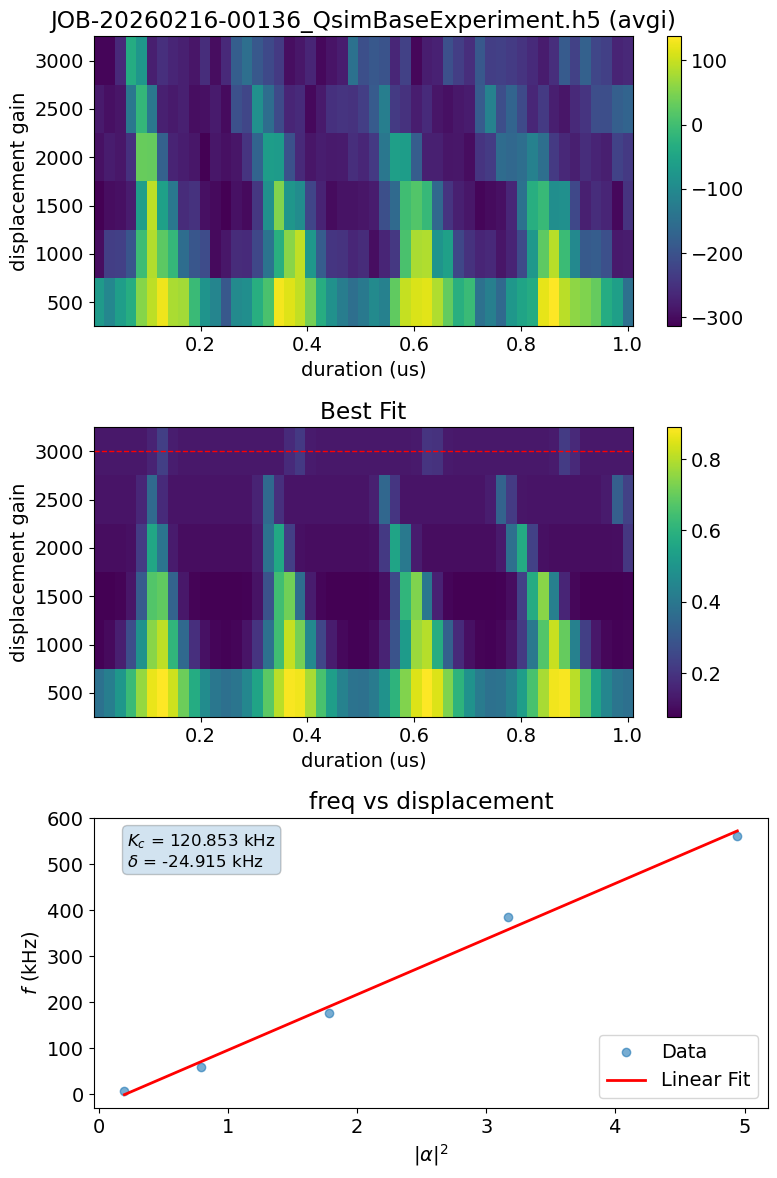

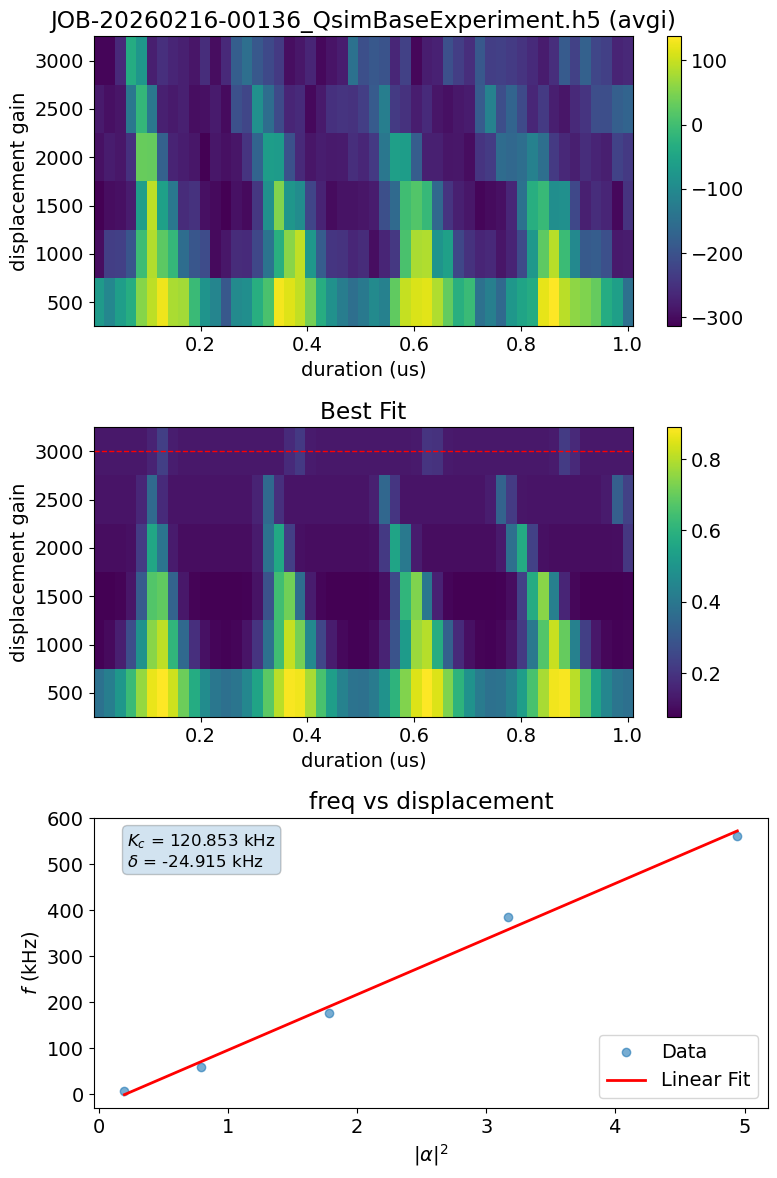

In [9]:
kerr_ramsey = meas.KerrCavityRamseyExperiment.from_h5file(r'D:\experiments\260214_qsim\data\JOB-20260216-00136_QsimBaseExperiment.h5')
kerr_ramsey.analyze()
kerr_ramsey.display()

# Qsim Wigner Tomography

## Generate Optimal Displacements 

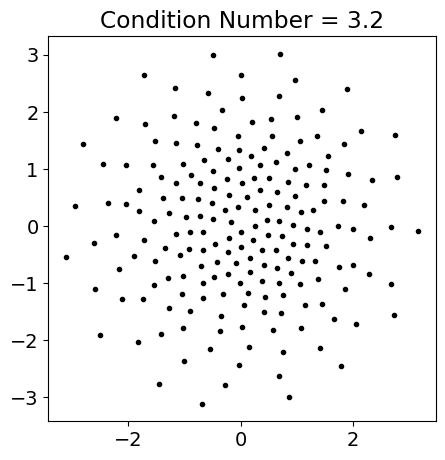

Displacements saved to D:\experiments\260217_qsim_wigner_prac\optimized_displacements_14.npy


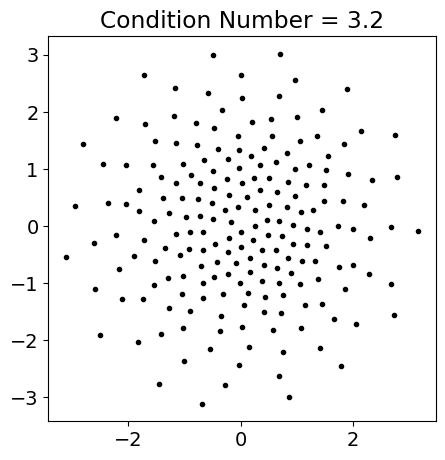

In [44]:
from fitting.wigner import OptimalDisplacementGeneration
n_photon = 13 # maximum photon number to consider
n_disps = 200 # number of displacements to use in the optimization
opt_alphas = OptimalDisplacementGeneration(FD = n_photon, n_disps=n_disps)
return_dict = opt_alphas.optimize(save_dir = station.experiment_path)

# Setup experiment

In [ ]:
kerr_wait_wigner_defaults = AttrDict(dict(
    expts=1,
    reps=100,
    rounds=1,
    qubits=[0],
    ro_stor=0, # storage mode number that gets read out in the end

    init_fock=False,
    displacement_path=return_dict['path'], # optimal displacement path
    perform_wigner=True,
    parity_fast=True,
    pulse_correction=True,

    wait_us_times=np.linspace(0, 5, 10).tolist(),
    swept_params = ['wait_us_time'],

    # Use SweepRunner to handle the sweeping
    # dummys=[0],
    # swept_params=['dummy'],

    normalize=False,
    post_select_pre_pulse=False,
    active_reset=False,
    man_reset=False, 
    storage_reset=False, 
    prepulse=True,
    postpulse=True,
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def kerr_wait_wigner_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    assert 'init_stor' in kwargs
    if not expt_cfg.init_fock:
        assert 'init_alpha' in kwargs

    print(expt_cfg)
    return expt_cfg


# wigner_runner = SweepRunner(
#     station=station,
#     ExptClass=meas.QsimWignerBaseExperiment,
#     ExptProgram=meas.KerrWaitProgram,
#     default_expt_cfg=kerr_wait_wigner_defaults,
#     sweep_param='wait_us_time',
#     preprocessor=kerr_wait_wigner_preproc,
#     postprocessor=None,
#     job_client=client,
# )

wigner_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.QsimWignerBaseExperiment,
    ExptProgram=meas.KerrWaitProgram,
    default_expt_cfg=kerr_wait_wigner_defaults,
    preprocessor=kerr_wait_wigner_preproc,
    postprocessor=None,
    job_client=client,
)

In [ ]:
wigner = wigner_runner.execute(
    reps=200,
    init_fock=False,
    init_alpha=1.0,
    init_stor=0,
    ro_stor=0,
    relax_delay=2500, 
    parity_fast = False,
    init_man_fock_state = '+',
    wait_us_times=[0],
    parity_check = True,
    parity_post_select = True,
    ringdown_wait = 3

)

{'expts': 1, 'reps': 200, 'rounds': 1, 'qubits': [0], 'ro_stor': 0, 'init_fock': False, 'displacement_path': 'D:\\experiments\\260217_qsim_wigner_prac\\optimized_displacements_11.npy', 'perform_wigner': True, 'parity_fast': False, 'pulse_correction': True, 'wait_us_times': [0], 'swept_params': ['wait_us_time'], 'normalize': False, 'post_select_pre_pulse': False, 'active_reset': False, 'man_reset': False, 'storage_reset': False, 'prepulse': True, 'postpulse': True, 'init_alpha': 1.0, 'init_stor': 0, 'relax_delay': 2500, 'init_man_fock_state': '+', 'parity_check': True, 'parity_post_select': True, 'ringdown_wait': 3}
Job submitted: JOB-20260312-00031 (queue position: 1)

[0.2s] Job JOB-20260312-00031: pending

[2.2s] Job JOB-20260312-00031: running
[WORKER] Loading QsimWignerBaseExperiment from experiments.qsim.qsim_base_wigner
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260312-00031_QsimWignerBaseExperiment.h5
[WORKER]   Program: KerrWaitProgram from experiments.qs

In [46]:
# test_wigner = meas.QsimWignerBaseExperiment(config_file=station.hardware_config_file, expt_params=kerr_wait_wigner_defaults)
# test_wigner.data = wigner.data
# test_wigner.outer_params = wigner.outer_params
# test_wigner.inner_params = wigner.inner_params
# test_wigner.outer_param = wigner.outer_param
# test_wigner.inner_param = wigner.inner_param
# test_wigner.pulse_correction = wigner.pulse_correction
# test_wigner.cfg = deepcopy(wigner.cfg)

# test_wigner.analyze_wigner(mode_state_num=10)

0 None
shape (201, 200)
max parity: 0.8546420333327474
max parity before scaling: 0.8091696376490423
Analyzing for wait_us_time=0, dummy=None
0 None
shape (201, 200)
max parity: 0.8546420333327474
max parity before scaling: 0.8091696376490423
Analyzing for wait_us_time=0, dummy=None
post_selecton_off purity: 0.8749636564747442


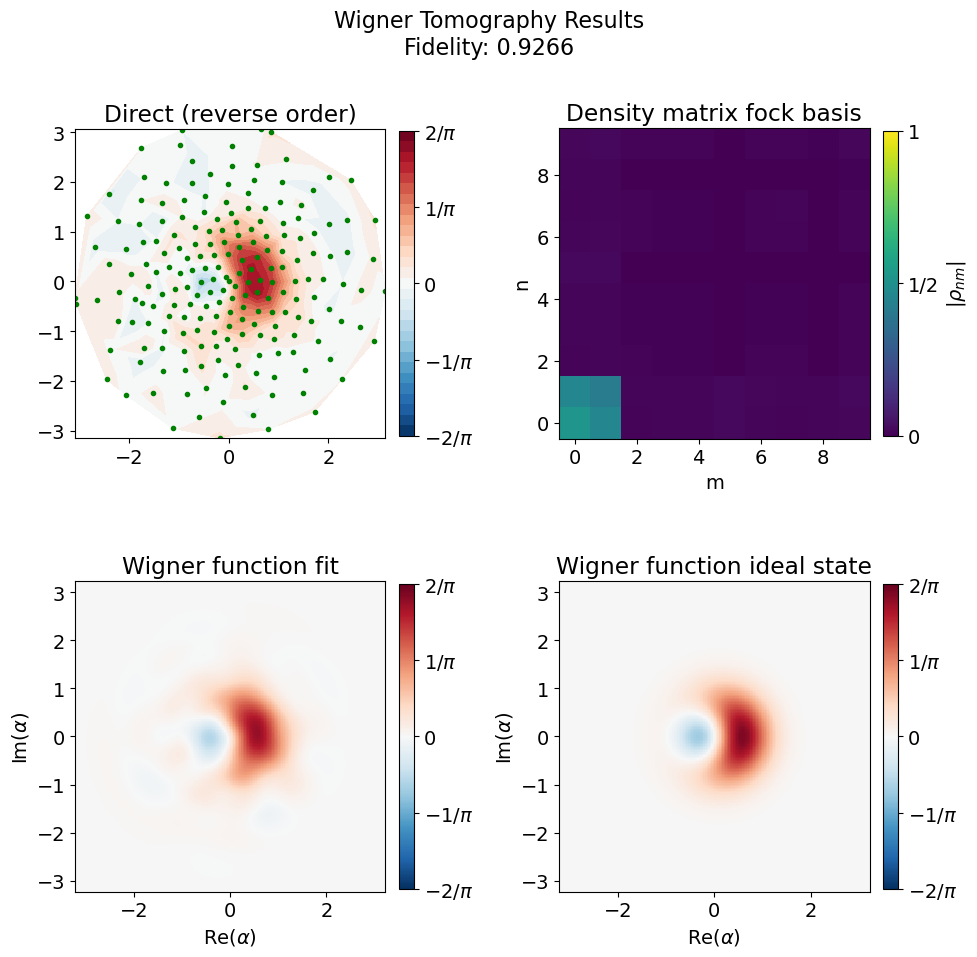

In [60]:
from fitting.fitting import wigner_purity_calculation
cutoff = 10
wigner.cfg.expt.parity_post_select = False
# ideal_state = (qt.basis(cutoff, 0)+qt.basis(cutoff, 4)).unit()
ideal_state = (qt.basis(cutoff, 0)+qt.basis(cutoff, 1)).unit()
# ideal_state = (qt.basis(cutoff, 1)).unit()
# ideal_state = (qt.coherent(cutoff, 1.0)).unit()
a = np.real(wigner_purity_calculation(wigner)[0])
wigner.analyze_wigner(cutoff=cutoff, debug=True)
wigner.display(rotate=True, initial_state=ideal_state, mode_state_num=cutoff, station=station, save_fig=False)
if wigner.cfg.expt.parity_post_select:
    print(f"post_selecton_on purity: {a[0]}")
else:
    print(f"post_selecton_off purity: {a[0]}")
    

In [7]:
idata_post_sliced = wigner.data['idata'][0, 0, 1, 0, 0::2]
parity_readout = wigner.data['parity_idata'][0, 0, 1, 0]
idata_post_sliced - parity_readout

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [46]:
np.shape(wigner.data['idata'])

(1, 1, 201, 2, 200)

In [58]:
from fitting.fitting import wigner_purity_calculation

wigner.cfg.expt.parity_post_select = False
a = np.real(wigner_purity_calculation(wigner)[0])
wigner.cfg.expt.parity_post_select = True
b = np.real(wigner_purity_calculation(wigner)[0])

print(f"post_selecton_off purity: {a[0]}")
print(f"post_selecton_on purity: {b[0]}")

0 None
shape (201, 200)
max parity: 0.8546420333327474
max parity before scaling: 0.8091696376490423
Analyzing for wait_us_time=0, dummy=None
0 None
  parity post-select: keeping 33931/40200 shots (84.4%)
shape (201, 200)
max parity: 0.94072887736183
max parity before scaling: 0.8906761136618379
Analyzing for wait_us_time=0, dummy=None
post_selecton_off purity: 0.8749636564747442
post_selecton_on purity: 0.9732086411861888


In [70]:
a

array([0.98230325])

In [100]:
print("class:", wigner.__class__)
print("module:", wigner.__class__.__module__)
print("idata shape:", wigner.data['idata'].shape)
print("parity_check:", wigner.cfg.expt.get('parity_check', False))
print("reps:", wigner.cfg.expt.get('reps'))
print("rounds:", wigner.cfg.expt.get('rounds', 1))

class: <class 'experiments.qsim.qsim_base_wigner.QsimWignerBaseExperiment'>
module: experiments.qsim.qsim_base_wigner
idata shape: (1, 1, 201, 2, 200)
parity_check: True
reps: 100
rounds: 1


In [83]:
wigner = wigner_runner.execute(
    reps=200,
    init_fock=False,
    init_alpha=1.0,
    init_stor=0,
    ro_stor=0,
    relax_delay=2500, 
    parity_fast = False,

    wait_us_times=np.linspace(0, 100, 26).tolist(),

    # sweep_start=0,
    # sweep_stop=5,
    # sweep_npts=3,
    # coupler_current = 0e-3,
)

{'expts': 1, 'reps': 200, 'rounds': 1, 'qubits': [0], 'ro_stor': 0, 'init_fock': False, 'displacement_path': 'D:\\experiments\\260217_qsim_wigner_prac\\optimized_displacements_5.npy', 'perform_wigner': True, 'parity_fast': False, 'pulse_correction': True, 'wait_us_times': [0.0, 4.0, 8.0, 12.0, 16.0, 20.0, 24.0, 28.0, 32.0, 36.0, 40.0, 44.0, 48.0, 52.0, 56.0, 60.0, 64.0, 68.0, 72.0, 76.0, 80.0, 84.0, 88.0, 92.0, 96.0, 100.0], 'swept_params': ['wait_us_time'], 'normalize': False, 'post_select_pre_pulse': False, 'active_reset': False, 'man_reset': False, 'storage_reset': False, 'prepulse': True, 'postpulse': True, 'init_alpha': 1.0, 'init_stor': 0, 'relax_delay': 2500}
Job submitted: JOB-20260307-00054 (queue position: 1)

[0.2s] Job JOB-20260307-00054: pending

[2.2s] Job JOB-20260307-00054: running
[WORKER] Loading QsimWignerBaseExperiment from experiments.qsim.qsim_base_wigner
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260307-00054_QsimWignerBaseExperiment.h5
[WO

RuntimeError: Job JOB-20260307-00054 failed: Job cancelled by user (Ctrl+C)

In [21]:
station.update_all_station_snapshots()

[CONFIG] Reusing existing hardware_config version CFG-HW-20260216-00028
[CONFIG] Reusing existing multiphoton_config version CFG-MP-20260121-00001
[CONFIG] Reusing existing man1_storage_swap version CFG-M1-20260216-00032
[CONFIG] Reusing existing floquet_storage_swap version CFG-FL-20260216-00001
Config snapshots for current station:
  hardware_config: CFG-HW-20260216-00028
  multiphoton_config: CFG-MP-20260121-00001
  man1_storage_swap: CFG-M1-20260216-00032
  floquet_storage_swap: CFG-FL-20260216-00001


{'hardware_config': 'CFG-HW-20260216-00028',
 'multiphoton_config': 'CFG-MP-20260121-00001',
 'man1_storage_swap': 'CFG-M1-20260216-00032',
 'floquet_storage_swap': 'CFG-FL-20260216-00001'}

# Connie's code(Floquet pulses within waittime)

In [68]:
qsim_wigner_defaults = AttrDict(dict(
    expts=1,
    reps=100,
    rounds=1,
    qubits=[0],
    ro_stor=0, # storage mode number that gets read out in the end

    init_fock=False,
    displacement_path="D:\experiments\260217_qsim_wigner_prac\optimized_displacements.npy", # optimal displacement path
    perform_wigner=True,
    parity_fast=False,
    pulse_correction=True,

    # wait_us_times=np.linspace(0, 5, 10).tolist(),
    # swept_params = ['wait_us_time'],

    # Use SweepRunner to handle the sweeping
    # dummys=[0],
    # swept_params=['dummy'],

    normalize=False,
    post_select_pre_pulse=False,
    active_reset=False,
    man_reset=False, 
    storage_reset=False, 
    prepulse=True,
    postpulse=True,
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def qsim_wigner_preproc(station, default_expt_cfg, **kwargs):
    assert 'swept_params' in kwargs
    assert len(kwargs['swept_params']) > 0

    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    assert 'init_stor' in kwargs
    if not expt_cfg.init_fock:
        assert 'init_alpha' in kwargs

    print(expt_cfg)
    return expt_cfg


# wigner_runner = SweepRunner(
#     station=station,
#     ExptClass=meas.QsimWignerBaseExperiment,
#     ExptProgram=meas.KerrWaitProgram,
#     default_expt_cfg=qsim_wigner_defaults,
#     sweep_param='wait_us_time',
#     preprocessor=qsim_wigner_preproc,
#     postprocessor=None,
#     job_client=client,
# )


<>:9: SyntaxWarning: invalid escape sequence '\e'
<>:9: SyntaxWarning: invalid escape sequence '\e'
C:\Users\26049\AppData\Local\Temp\ipykernel_14332\3306428629.py:9: SyntaxWarning: invalid escape sequence '\e'
  displacement_path="D:\experiments\260217_qsim_wigner_prac\optimized_displacements.npy", # optimal displacement path


In [69]:
wigner_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.QsimWignerBaseExperiment,
    # ExptProgram=meas.KerrWaitProgram,
    ExptProgram=meas.SidebandScrambleProgram,
    default_expt_cfg=qsim_wigner_defaults,
    preprocessor=qsim_wigner_preproc,
    postprocessor=None,
    job_client=client,
)

floquet_cycles = np.arange(1, 100, step=10)
print(floquet_cycles)

for floquet_cycle in floquet_cycles:
    wigner = wigner_runner.execute(
        reps=200,
        init_fock=False,
        init_alpha=1.0,
        init_stor=0,
        ro_stor=0,
        relax_delay=8000,
        swap_stors=[1, 3],
        update_phases=True,
        floquet_cycles=[floquet_cycle],
        swept_params=['floquet_cycle'],
    )

[ 1 11 21 31 41 51 61 71 81 91]
{'expts': 1, 'reps': 200, 'rounds': 1, 'qubits': [0], 'ro_stor': 0, 'init_fock': False, 'displacement_path': 'D:\\experiments°217_qsim_wigner_prac\\optimized_displacements.npy', 'perform_wigner': True, 'parity_fast': False, 'pulse_correction': True, 'normalize': False, 'post_select_pre_pulse': False, 'active_reset': False, 'man_reset': False, 'storage_reset': False, 'prepulse': True, 'postpulse': True, 'init_alpha': 1.0, 'init_stor': 0, 'relax_delay': 8000, 'swap_stors': [1, 3], 'update_phases': True, 'floquet_cycles': [1], 'swept_params': ['floquet_cycle']}
Job submitted: JOB-20260217-00126 (queue position: 1)

[0.1s] Job JOB-20260217-00126: pending

[2.1s] Job JOB-20260217-00126: running
[WORKER] Loading QsimWignerBaseExperiment from experiments.qsim.qsim_base_wigner
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260217-00126_QsimWignerBaseExperiment.h5
[WORKER]   Program: SidebandScrambleProgram from experiments.qsim.sideband_scramb

RuntimeError: Job JOB-20260217-00126 failed: FileNotFoundError: [Errno 2] No such file or directory: 'D:\\experiments°217_qsim_wigner_prac\\optimized_displacements.npy'
Traceback (most recent call last):
  File "D:\python\multimode_expts\job_server\worker.py", line 366, in _execute_job
    data_file_path, expt_pickle_path = self._run_experiment(ExptClass, expt_config, job)
                                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\python\multimode_expts\job_server\worker.py", line 552, in _run_experiment
    expt.go(
  File "D:\python\multimode_expts\slab\experiment.py", line 166, in go
    data=self.acquire(progress)
         ^^^^^^^^^^^^^^^^^^^^^^
  File "D:\python\multimode_expts\experiments\qsim\qsim_base_wigner.py", line 81, in acquire
    alpha_list = np.load(self.cfg.expt["displacement_path"])  # complex ndarray
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\python\multimode_expts\.pixi\envs\default\Lib\site-packa

# Purity Calculation

In [5]:
import os, sys, pickle, glob
from collections import defaultdict

REPO_ROOT = r"D:\python\multimode_expts" 
BASE_DIR  = r"D:\experiments\260214\data"
OBJ_DIR   = os.path.join(BASE_DIR, "expt_objs")

RUN_PREFIX = "JOB-20260217-00148_QsimWignerBaseExperiment.h5"  
JOB_START  = 20
JOB_END    = 54  # inclusive

# freq_list_force = [50, 100]
# kerr_gain_list_force = [0, 10000]
freq_list_force = None
kerr_gain_list_force = None

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

try:
    from experiments.qsim.t2_cavity_fluxexcursion import KerrCavityRamseyExcursionExperiment  # noqa: F401
except Exception as e:
    print("[WARN] Pre-import failed (may still load):", e)

def _pkl_path_for_job(job_num: int) -> str:
    return os.path.join(OBJ_DIR, f"{RUN_PREFIX}-{job_num:05d}_expt.pkl")

def load_expt_from_pkl(pkl_path: str):
    try:
        with open(pkl_path, "rb") as f:
            return pickle.load(f)
    except Exception as e_pickle:
        try:
            import dill
            with open(pkl_path, "rb") as f:
                return dill.load(f)
        except Exception as e_dill:
            raise RuntimeError(
                f"Failed to load: {pkl_path}\n"
                f"pickle error: {e_pickle}\n"
                f"dill error: {e_dill}"
            )

def safe_postprocess(expt):

    for fn in ["analyze", "postprocess", "process"]:
        if hasattr(expt, fn):
            try:
                getattr(expt, fn)()
            except Exception as e:
                print(f"[WARN] {fn} failed on {getattr(expt, 'fname', 'expt')}: {e}")

def rebuild_cavity_list_list(expts, freq_list=None, kerr_gain_list=None):

    by_freq_gain = defaultdict(dict)

    kept = []
    skipped = 0
    for e in expts:
        try:
            f = float(e.cfg.expt.kerr_freq)
            g = float(e.cfg.expt.kerr_gain)
            by_freq_gain[f][g] = e
            kept.append(e)
        except Exception:
            skipped += 1

    if freq_list is None:
        freq_list = sorted(by_freq_gain.keys())
    if kerr_gain_list is None:
        all_gains = set()
        for d in by_freq_gain.values():
            all_gains |= set(d.keys())
        kerr_gain_list = sorted(all_gains)

    cavity_list_list = []
    missing = []
    for f in freq_list:
        row = []
        for g in kerr_gain_list:
            if f in by_freq_gain and g in by_freq_gain[f]:
                row.append(by_freq_gain[f][g])
            else:
                missing.append((f, g))
        cavity_list_list.append(row)

    return cavity_list_list, freq_list, kerr_gain_list, kept, skipped, missing

expts = []
missing_pkls = []
for j in range(JOB_START, JOB_END + 1):
    p = _pkl_path_for_job(j)
    if os.path.exists(p):
        expts.append(load_expt_from_pkl(p))
    else:
        missing_pkls.append(p)

print(f"Loaded expts: {len(expts)}")
if missing_pkls:
    print(f"[WARN] Missing pkl files: {len(missing_pkls)} (first 3 shown)")
    for p in missing_pkls[:3]:
        print(" ", p)

cavity_list_list, freq_list, kerr_gain_list, kept, skipped, missing = rebuild_cavity_list_list(
    expts,
    freq_list=freq_list_force,
    kerr_gain_list=kerr_gain_list_force,
)

print("Rebuilt cavity_list_list.")
print("  freq_list      =", freq_list)
print("  kerr_gain_list =", kerr_gain_list)
print("  row lengths    =", [len(r) for r in cavity_list_list])
print("  skipped(no cfg.expt.kerr_*) =", skipped)
if missing:
    print(f"[WARN] Missing (freq,gain) combos: {len(missing)} (first 10 shown)")
    print(missing[:10])


Loaded expts: 0
[WARN] Missing pkl files: 35 (first 3 shown)
  D:\experiments\260214\data\expt_objs\JOB-20260217-00148_QsimWignerBaseExperiment.h5-00020_expt.pkl
  D:\experiments\260214\data\expt_objs\JOB-20260217-00148_QsimWignerBaseExperiment.h5-00021_expt.pkl
  D:\experiments\260214\data\expt_objs\JOB-20260217-00148_QsimWignerBaseExperiment.h5-00022_expt.pkl
Rebuilt cavity_list_list.
  freq_list      = []
  kerr_gain_list = []
  row lengths    = []
  skipped(no cfg.expt.kerr_*) = 0


## Connie's data set

In [34]:
import pickle
import qutip as qt
pkl_files = [
"D:\\experiments\\260128_qsim_wigner\\expt_objs\\JOB-20260204-00129_expt.pkl",
"D:\\experiments\\260128_qsim_wigner\\expt_objs\\JOB-20260204-00131_expt.pkl",
"D:\\experiments\\260128_qsim_wigner\\expt_objs\\JOB-20260204-00133_expt.pkl",
"D:\\experiments\\260128_qsim_wigner\\expt_objs\\JOB-20260204-00134_expt.pkl",
"D:\\experiments\\260128_qsim_wigner\\expt_objs\\JOB-20260204-00136_expt.pkl",
"D:\\experiments\\260128_qsim_wigner\\expt_objs\\JOB-20260204-00138_expt.pkl"
]

cutoff = 10
ideal_state = (qt.coherent(cutoff, 1.0)).unit()
floquet_cycles = np.arange(1, 50, step=5)
outer_param = []
purity_list = []
rho_list = []
for i, pkl_file in enumerate(pkl_files):
    with open(pkl_file, "rb") as f:
        test_wigner = pickle.load(f)
        test_wigner.analyze_wigner(cutoff=cutoff, debug=True)
        test_wigner.display(rotate=True, initial_state=ideal_state, mode_state_num=cutoff, station=station, save_fig=False)
        # plt.show()
        plt.clf()
        # print(test_wigner.outer_param)
        # print(test_wigner.outer_params)
        # print(test_wigner.inner_param)
        rho = test_wigner.data["wigner_outputs"]['rho'][0][0]
        rho = np.array(rho)
        outer_param.append(test_wigner.outer_params)
        # ax.pcolor(*np.meshgrid(np.arange(np.shape(rho)[0]),
        #                        np.arange(np.shape(rho)[0])), 
        #           np.abs(rho),
        #           cmap='viridis', vmin=0, vmax=1)
        # purity = 
        purity_list.append(np.trace(np.matmul(rho, rho)))
        rho_list.append(rho)
_n = len(pkl_files)
_row = 3
_col = _n//_row if (_n % _row == 0) else _n//_row + 1
# fig, ax = plt.subplots(_row, _col, figsize = (6,6))
# for i in range(_n):
#     ax[i % _row, i // _row ].pcolor(*np.meshgrid(np.arange(np.shape(rho)[0]),
#                                                  np.arange(np.shape(rho)[0])), 
#                                     np.abs(rho),
#                                     cmap='viridis', 
#                                     vmin=0, 
#                                     vmax=1)
# ax[_n % _row, _n // _row ].scatter(outer_param,
#                                    purity_list)
# ax[_n % _row, _n // _row ].set_xlabel(f'{test_wigner.outer_param}')
# ax[_n % _row, _n // _row ].set_ylabel("Purity")

1 None
shape (201, 50)
max parity: 1.0907067808297253
max parity before scaling: 0.9188034188034189
Analyzing for floquet_cycle=1, dummy=None
6 None
shape (201, 50)
max parity: 1.0399762328841566
max parity before scaling: 0.8760683760683762
Analyzing for floquet_cycle=6, dummy=None
11 None
shape (201, 50)
max parity: 1.065341506856941
max parity before scaling: 0.8974358974358975
Analyzing for floquet_cycle=11, dummy=None
16 None
shape (201, 50)
max parity: 1.065341506856941
max parity before scaling: 0.8974358974358975
Analyzing for floquet_cycle=16, dummy=None
21 None
shape (201, 50)
max parity: 1.0399762328841566
max parity before scaling: 0.8760683760683762
Analyzing for floquet_cycle=21, dummy=None
26 None
shape (201, 50)
max parity: 1.0399762328841564
max parity before scaling: 0.876068376068376
Analyzing for floquet_cycle=26, dummy=None


<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

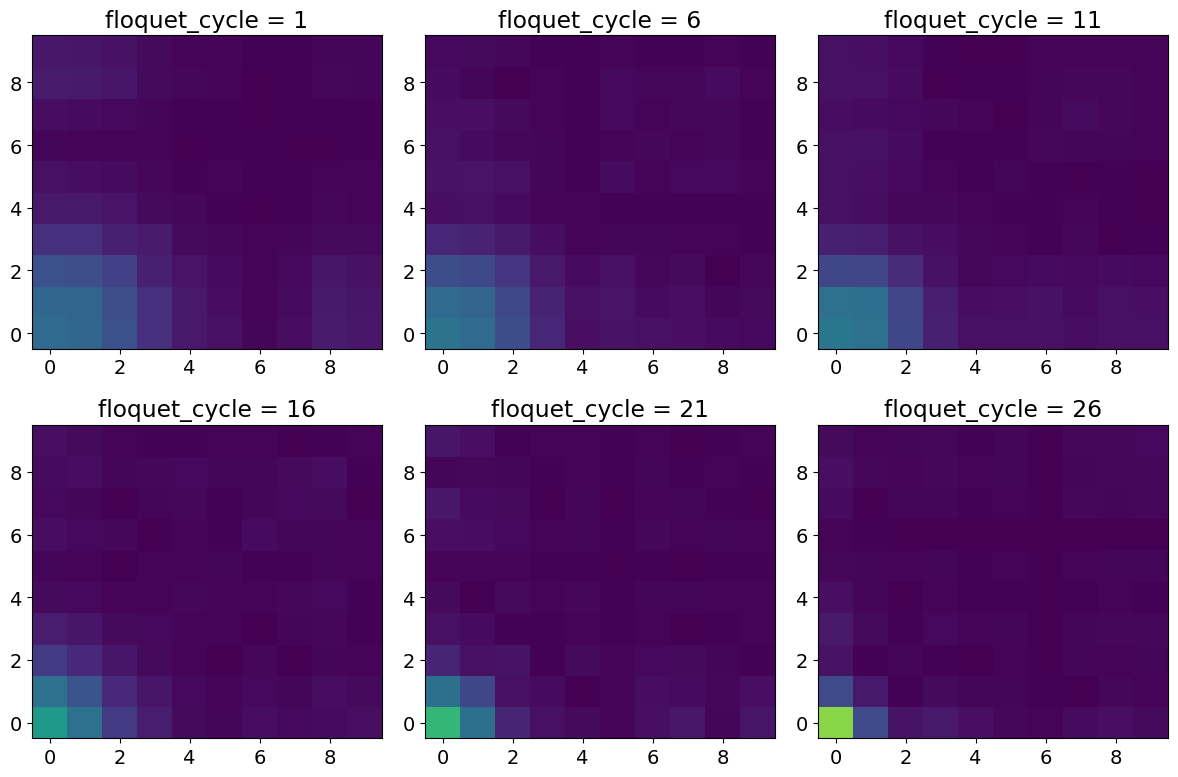

In [35]:
_n = len(pkl_files)
_row = 3
_col = _n//_row if (_n % _row == 0) else _n//_row + 1
fig, ax = plt.subplots(_col,_row, figsize = (12,8))
# _n -=1
for i in range(_n):
    rho = rho_list[i]
    ax[i // _row, i % _row ].pcolor(*np.meshgrid(np.arange(np.shape(rho)[0]),
                                                 np.arange(np.shape(rho)[0])), 
                                    np.abs(rho),
                                    cmap='viridis', 
                                    vmin=0, 
                                    vmax=1)
    ax[i // _row, i % _row ].set_title(f"{test_wigner.outer_param} = {outer_param[i][0]}")

# ax[_n % _row, _n // _row ].scatter(outer_param,
#                                    purity_list)
# ax[_n % _row, _n // _row ].set_xlabel(f'{test_wigner.outer_param}')
# ax[_n % _row, _n // _row ].set_ylabel("Purity")

fig.tight_layout()

d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\matplotlib\collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


Text(0, 0.5, 'Purity')

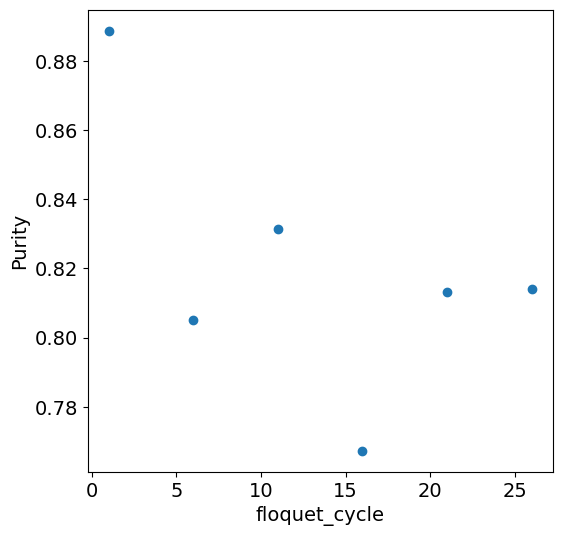

In [36]:
fig, ax = plt.subplots(figsize = (6,6))

ax.scatter(outer_param,
                                   purity_list)
ax.set_xlabel(f'{test_wigner.outer_param}')
ax.set_ylabel("Purity")

Analyzing for floquet_cycle=26, dummy=None


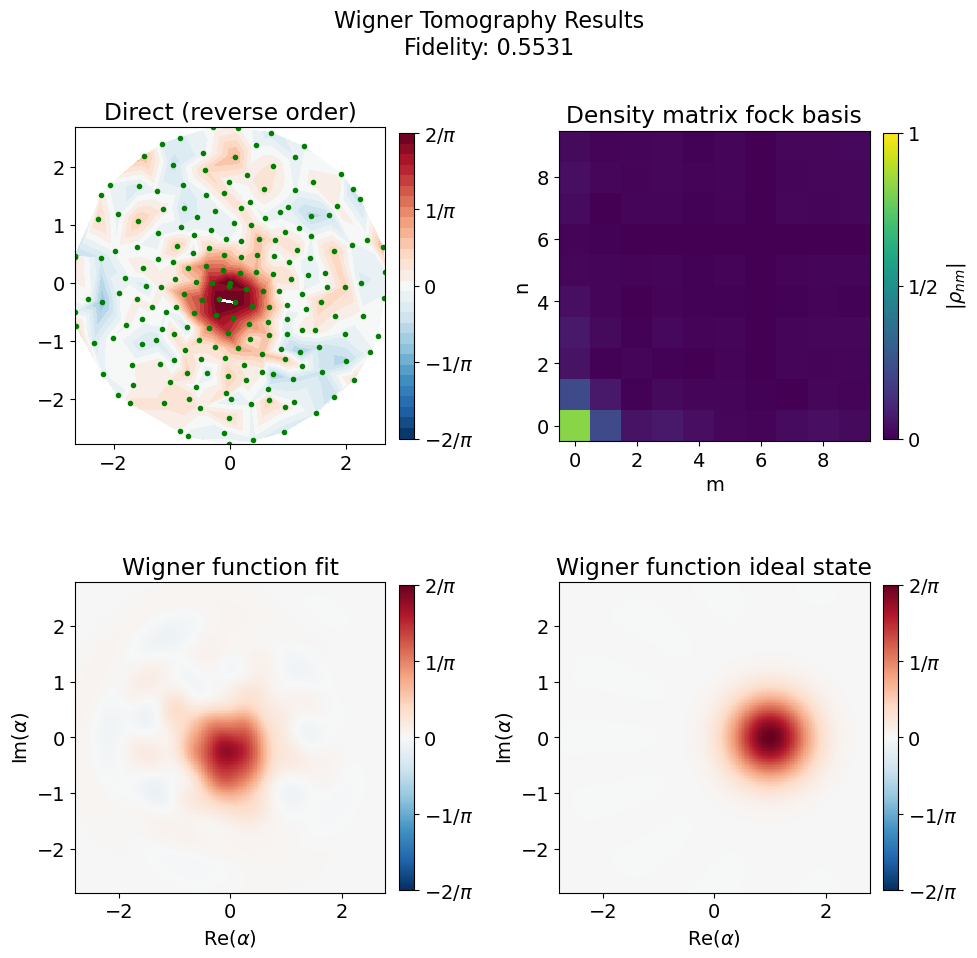

In [39]:
cutoff = 10
test_wigner.display(rotate=True, initial_state=ideal_state, mode_state_num=cutoff, station=station, save_fig=False)
# fig, ax = plt.subplots(figsize = (2,2))
rho = test_wigner.data["wigner_outputs"]['rho'][0][0]
rho = np.array(rho)
# ax.pcolor(*np.meshgrid(np.arange(np.shape(rho)[0]),
#                        np.arange(np.shape(rho)[0])), 
#           np.abs(rho),
#           cmap='viridis', vmin=0, vmax=1)
purity = np.trace(np.matmul(rho, rho))

## Guan's data set

D:\experiments\260214\data\JOB-20260217-00148_QsimWignerBaseExperiment.h5 and JOB-20260216-00167_QsimWignerBaseExperiment.h5

In [2]:
import pickle
pkl_files = [
"D:\\experiments\\260214_qsim\\expt_objs\\JOB-20260217-00148_expt.pkl",
"D:\\experiments\\260214_qsim\\expt_objs\\JOB-20260216-00167_expt.pkl",
]

wigner_list = []
for i, pkl_file in enumerate(pkl_files):
    with open(pkl_file, "rb") as f:
        wigner_list.append( pickle.load(f))

0.0 None
shape (201, 200)
max parity: 0.9604733986616811
max parity before scaling: 0.8920985556499577
4.0 None
shape (201, 200)
max parity: 0.9604733986616811
max parity before scaling: 0.796516567544605
8.0 None
shape (201, 200)
max parity: 0.9604733986616811
max parity before scaling: 0.8655480033984707
12.0 None
shape (201, 200)
max parity: 0.9604733986616811
max parity before scaling: 0.7062446898895497
16.0 None
shape (201, 200)
max parity: 0.9604733986616811
max parity before scaling: 0.7805862361937128
20.0 None
shape (201, 200)
max parity: 0.9604733986616811
max parity before scaling: 0.7115548003398472
24.0 None
shape (201, 200)
max parity: 0.9604733986616811
max parity before scaling: 0.7487255734919287
28.0 None
shape (201, 200)
max parity: 0.9604733986616811
max parity before scaling: 0.6531435853865762
32.0 None
shape (201, 200)
max parity: 0.9604733986616811
max parity before scaling: 0.6850042480883604
36.0 None
shape (201, 200)
max parity: 0.9604733986616811
max parity

D:\python\multimode_expts\fitting\wigner.py:373: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(2, 2, figsize=(10, 10))


Analyzing for wait_us_time=84.0, dummy=None
Analyzing for wait_us_time=88.0, dummy=None
Analyzing for wait_us_time=92.0, dummy=None
Analyzing for wait_us_time=96.0, dummy=None
Analyzing for wait_us_time=100.0, dummy=None


d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\matplotlib\collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


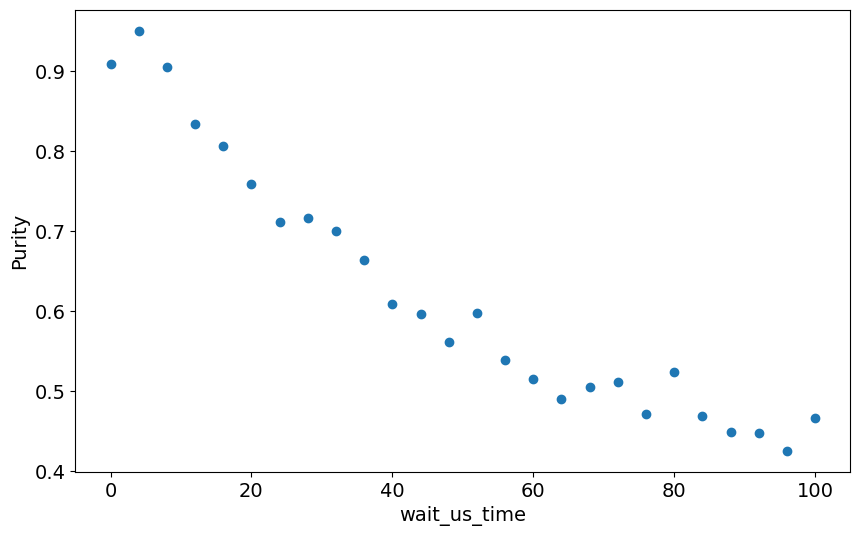

0.0 None
shape (201, 100)
max parity: 1.0310303218326642
max parity before scaling: 0.9165613147914035
0.25 None
shape (201, 100)
max parity: 1.0310303218326642
max parity before scaling: 0.8638853771597136
0.5 None
shape (201, 100)
max parity: 1.0310303218326642
max parity before scaling: 0.8954909397387274
0.75 None
shape (201, 100)
max parity: 1.0310303218326642
max parity before scaling: 0.9060261272650654
1.0 None
shape (201, 100)
max parity: 1.0310303218326642
max parity before scaling: 0.7796038769490098
1.25 None
shape (201, 100)
max parity: 1.0310303218326642
max parity before scaling: 0.7585335018963338
1.5 None
shape (201, 100)
max parity: 1.0310303218326642
max parity before scaling: 0.8533501896333756
1.75 None
shape (201, 100)
max parity: 1.0310303218326642
max parity before scaling: 0.7585335018963338
2.0 None
shape (201, 100)
max parity: 1.0310303218326642
max parity before scaling: 0.7901390644753478
2.25 None
shape (201, 100)
max parity: 1.0310303218326642
max parity 

D:\python\multimode_expts\fitting\wigner.py:373: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(2, 2, figsize=(10, 10))


Analyzing for wait_us_time=5.25, dummy=None
Analyzing for wait_us_time=5.5, dummy=None
Analyzing for wait_us_time=5.75, dummy=None
Analyzing for wait_us_time=6.0, dummy=None
Analyzing for wait_us_time=6.25, dummy=None
Analyzing for wait_us_time=6.5, dummy=None
Analyzing for wait_us_time=6.75, dummy=None
Analyzing for wait_us_time=7.0, dummy=None
Analyzing for wait_us_time=7.25, dummy=None
Analyzing for wait_us_time=7.5, dummy=None
Analyzing for wait_us_time=7.75, dummy=None
Analyzing for wait_us_time=8.0, dummy=None
Analyzing for wait_us_time=8.25, dummy=None
Analyzing for wait_us_time=8.5, dummy=None
Analyzing for wait_us_time=8.75, dummy=None
Analyzing for wait_us_time=9.0, dummy=None
Analyzing for wait_us_time=9.25, dummy=None
Analyzing for wait_us_time=9.5, dummy=None
Analyzing for wait_us_time=9.75, dummy=None
Analyzing for wait_us_time=10.0, dummy=None


d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\matplotlib\collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


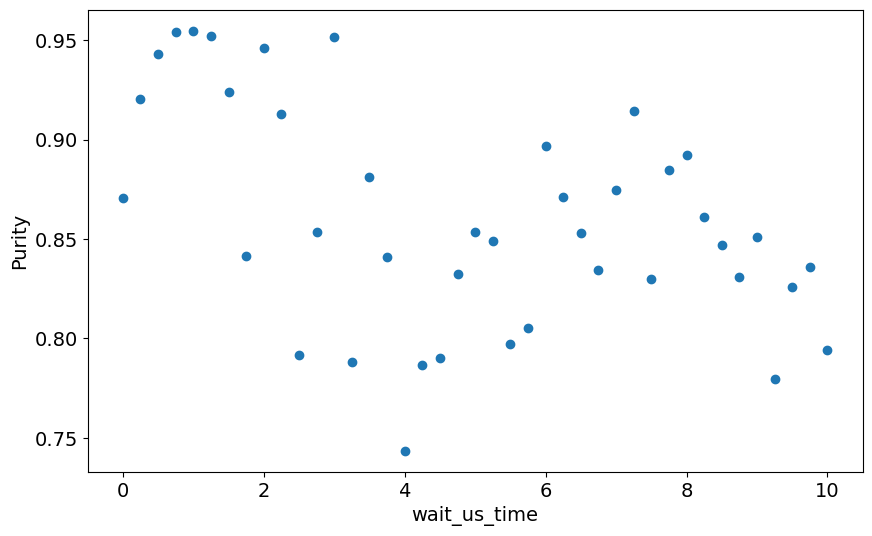

In [ ]:
from fitting.fitting import wigner_purity_calculation
purity = wigner_purity_calculation(wigner_list,
                                   plot_purity= True)

d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


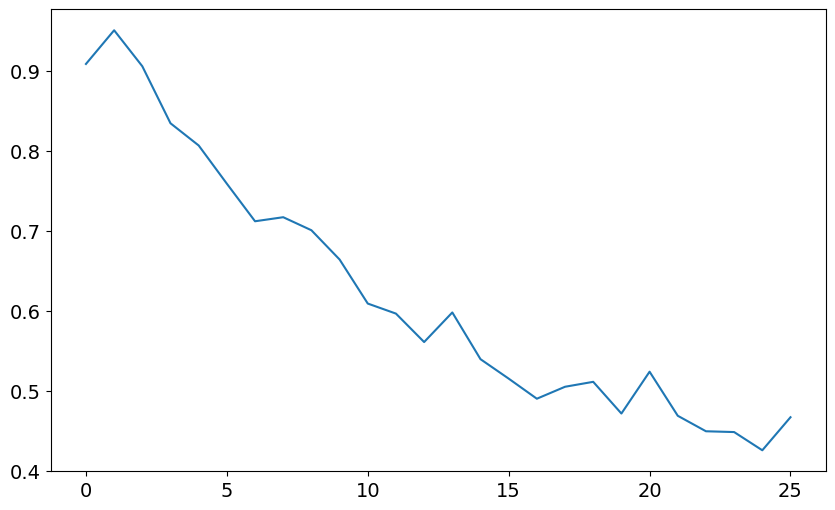

In [69]:
plt.plot(purity[0])

TypeError: Dimensions of C (26, 1, 10, 10) should be one smaller than X(26) and Y(26) while using shading='flat' see help(pcolor)

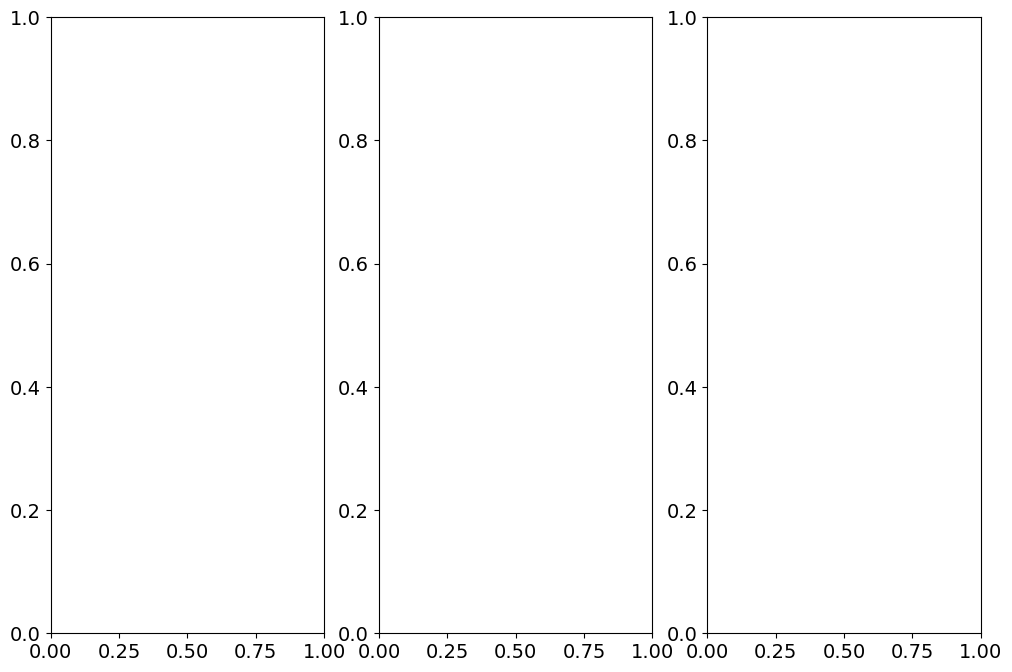

In [39]:
_n = len(wigner_list)
_row = 3
_col = _n//_row if (_n % _row == 0) else _n//_row + 1
fig, ax = plt.subplots(_col,_row, figsize = (12,8))
# _n -=1
for i in range(_n):
    rho = rho_list[i]
    if _col != 1:
        ax[i // _row, i % _row ].pcolor(*np.meshgrid(np.arange(np.shape(rho)[0]),
                                                    np.arange(np.shape(rho)[0])), 
                                        np.abs(rho),
                                        cmap='viridis', 
                                        vmin=0, 
                                        vmax=1)
        ax[i // _row, i % _row ].set_title(f"{test_wigner.outer_param} = {outer_param[i][0]}")
    else:
        ax[i % _row ].pcolor(*np.meshgrid(np.arange(np.shape(rho)[0]),
                                                    np.arange(np.shape(rho)[0])), 
                             np.abs(rho),
                             cmap='viridis', 
                             vmin=0, 
                             vmax=1)
        ax[i % _row ].set_title(f"{test_wigner.outer_param} = {outer_param[i][0]}")

fig.tight_layout()

d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

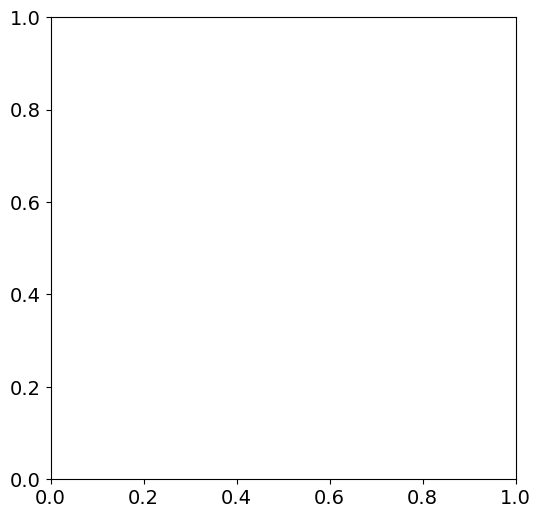

In [75]:
fig, ax = plt.subplots(figsize = (6,6))

ax.scatter(outer_param,
                                   purity_list)
ax.set_xlabel(f'{test_wigner.outer_param}')
ax.set_ylabel("Purity")

Text(0.5, 1.0, 'D:\\experiments\\260214_qsim\\expt_objs\\JOB-20260216-00167_expt.pkl')

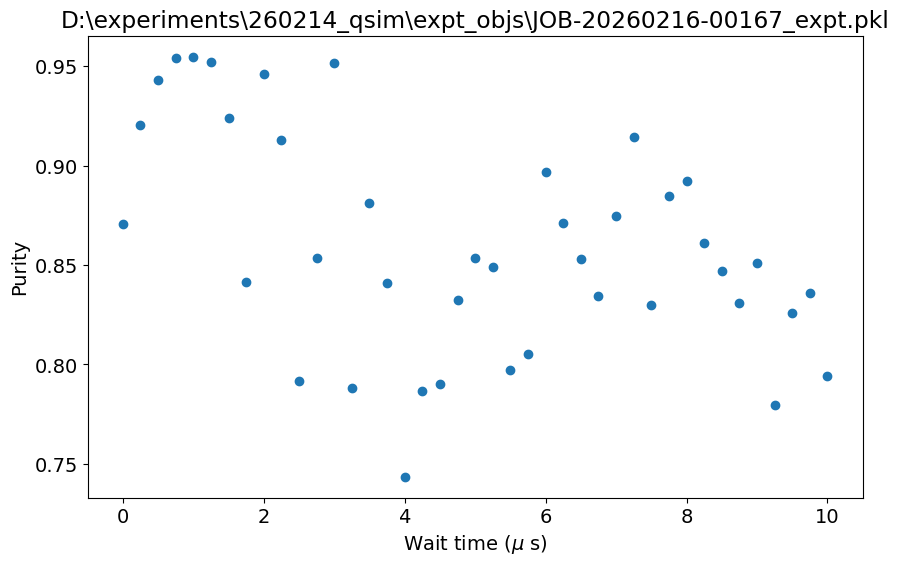

In [121]:
idx = 1
fig, ax = plt.subplots()
ax.scatter(outer_param_list[idx],
            purity_list[idx])
ax.set_xlabel('Wait time ($\\mu$ s)')
ax.set_ylabel("Purity")
ax.set_title(f"{pkl_files[idx]}")

In [ ]:

purity_list
rho_list
outer_param_list
inner_param_list

# Parity Post-selection Verification

In [20]:
default_cfg = AttrDict(dict(
    expts=1,
    reps=100,
    rounds=1,
    qubits=[0],
    ro_stor=0, # storage mode number that gets read out in the end

    init_fock=False,
    perform_wigner=False,
    parity_fast=False,
    dummys=[0],
    swept_params = ['dummy'],
    normalize=False,
    active_reset=False,
    man_reset=False, 
    parity_check = True,
    storage_reset=False, 
    prepulse=False,
    postpulse=False,
))

debug_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.QsimBaseExperiment,
    ExptProgram=meas.qsim.t2_cavity_fluxexcursion.ParityDebuggingProgram,
    default_expt_cfg=default_cfg,
    postprocessor=None,
    job_client=client,
)

debug = debug_runner.execute(
    init_stor = 0,
    reps = 10000,
    relax_delay = 2500,
    phase_second_pulse = 180
)


Job submitted: JOB-20260316-00089 (queue position: 1)

[0.1s] Job JOB-20260316-00089: pending

[2.1s] Job JOB-20260316-00089: running
[WORKER] Loading QsimBaseExperiment from experiments.qsim.qsim_base
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260316-00089_QsimBaseExperiment.h5
[WORKER]   Program: ParityDebuggingProgram from experiments.qsim.t2_cavity_fluxexcursion
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.5mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
  0%|                                                    | 0/1 [00:00<?, ?it/s]
[32.3s] Job JOB-20260316-00089: completed
100%|████████████████████████████████████████████| 1/1 [00:25<00:00, 25.20s/it]
Saving D:\experiments\260217_qsim_wigner_prac\data\JOB-20260316-00089_QsimBaseExperiment.h5
[WORKER] Saving expt object to: D:\experiments\260217_qsim_wigner_prac\expt_objs\JOB-20260316-00089_expt.pkl

Job completed! Data: D:\experiments\260217_qsim_wigner

In [26]:
data_to_analyze = np.array(debug.data['idata'])
data_to_analyze_q = np.array(debug.data['qdata'])
parity = data_to_analyze[:,0::2]
man_readout = data_to_analyze[:,1::2]
man_readout_q = data_to_analyze_q[:,1::2]
parity = parity[0]
man_readout = man_readout[0]
man_readout_q = man_readout_q[0]
thr = debug.cfg.device.readout.threshold[0]

In [27]:
thr = debug.cfg.device.readout.threshold[0]
even_par_res = []
odd_par_res = []
even_par_res_q = []
odd_par_res_q = []
for idx, par in enumerate(parity):
    if par > thr: #odd parity
        odd_par_res.append(man_readout[idx])
        odd_par_res_q.append(man_readout_q[idx])
    else:
        even_par_res.append(man_readout[idx])
        even_par_res_q.append(man_readout_q[idx])

C:\Users\26049\AppData\Local\Temp\ipykernel_51712\3375530106.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Text(0.5, 0, 'I (ADC unit)')

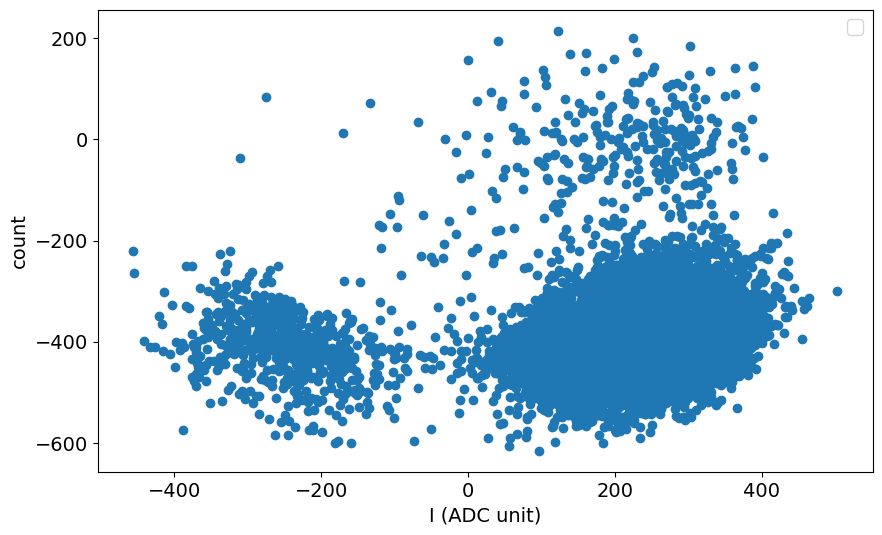

In [28]:
fig, ax = plt.subplots()
ax.scatter(man_readout, man_readout_q)
ax.legend()
ax.set_ylabel("count")
ax.set_xlabel("I (ADC unit)")

Text(0.5, 0, 'I (ADC unit)')

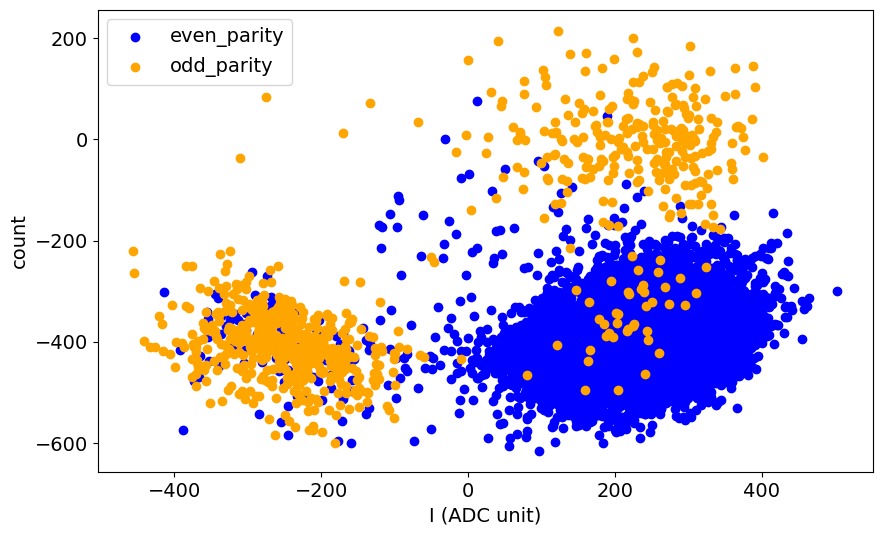

In [29]:
fig, ax = plt.subplots()
ax.scatter(even_par_res, even_par_res_q, label = 'even_parity', color = 'blue')
ax.scatter(odd_par_res, odd_par_res_q, label = 'odd_parity', color = 'orange')
ax.legend()
ax.set_ylabel("count")
ax.set_xlabel("I (ADC unit)")

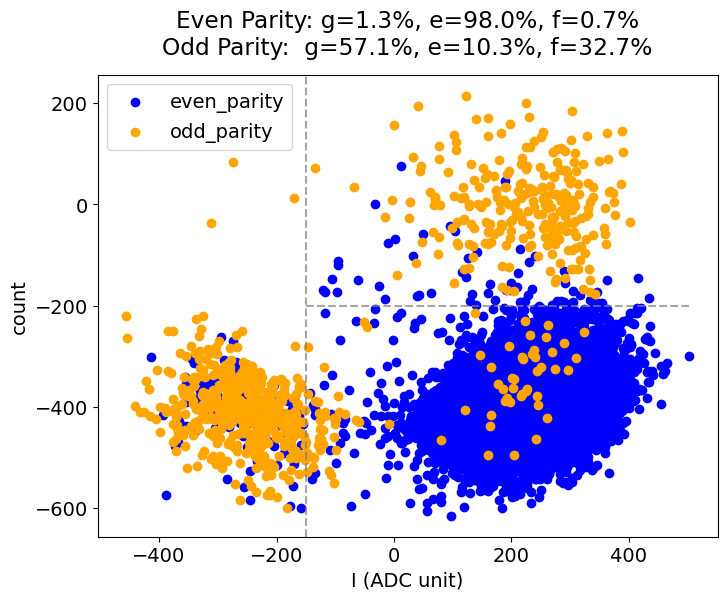

In [30]:
import numpy as np
import matplotlib.pyplot as plt

even_I = np.array(even_par_res)
even_count = np.array(even_par_res_q)
odd_I = np.array(odd_par_res)
odd_count = np.array(odd_par_res_q)

I_th = -150
count_th = -200

def calc_populations(I_data, count_data):
    total = len(I_data)
    if total == 0: return 0, 0, 0
    
    g_mask = I_data < I_th
    e_mask = (I_data >= I_th) & (count_data < count_th)
    f_mask = (I_data >= I_th) & (count_data >= count_th)
    
    g_pct = np.sum(g_mask) / total * 100
    e_pct = np.sum(e_mask) / total * 100
    f_pct = np.sum(f_mask) / total * 100
    
    return g_pct, e_pct, f_pct

even_g, even_e, even_f = calc_populations(even_I, even_count)
odd_g,  odd_e,  odd_f  = calc_populations(odd_I, odd_count)

fig, ax = plt.subplots(figsize=(8, 6)) 

ax.scatter(even_par_res, even_par_res_q, label='even_parity', color='blue')
ax.scatter(odd_par_res, odd_par_res_q, label='odd_parity', color='orange')

ax.axvline(x=I_th, color='gray', linestyle='--', alpha=0.7) 
ax.hlines(y=count_th, xmin=I_th, xmax=max(np.max(even_I), np.max(odd_I)), color='gray', linestyle='--', alpha=0.7)

title_text = (
    f"Even Parity: g={even_g:.1f}%, e={even_e:.1f}%, f={even_f:.1f}%\n"
    f"Odd Parity:  g={odd_g:.1f}%, e={odd_e:.1f}%, f={odd_f:.1f}%"
)
ax.set_title(title_text, pad=15) 

ax.legend()
ax.set_ylabel("count")
ax.set_xlabel("I (ADC unit)")

plt.show()

### Doing Wigner Tomography

In [45]:
kerr_wait_wigner_defaults = AttrDict(dict(
    expts=1,
    reps=100,
    rounds=1,
    qubits=[0],
    ro_stor=0, # storage mode number that gets read out in the end

    init_fock=False,
    displacement_path=return_dict['path'], # optimal displacement path
    perform_wigner=True,
    parity_fast=True,
    pulse_correction=True,

    wait_us_times=np.linspace(0, 5, 10).tolist(),
    swept_params = ['wait_us_time'],

    # Use SweepRunner to handle the sweeping
    # dummys=[0],
    # swept_params=['dummy'],

    normalize=False,
    post_select_pre_pulse=False,
    active_reset=False,
    man_reset=False, 
    storage_reset=False, 
    prepulse=True,
    postpulse=True,
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def kerr_wait_wigner_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    assert 'init_stor' in kwargs
    if not expt_cfg.init_fock:
        assert 'init_alpha' in kwargs

    print(expt_cfg)
    return expt_cfg


# wigner_runner = SweepRunner(
#     station=station,
#     ExptClass=meas.QsimWignerBaseExperiment,
#     ExptProgram=meas.KerrWaitProgram,
#     default_expt_cfg=kerr_wait_wigner_defaults,
#     sweep_param='wait_us_time',
#     preprocessor=kerr_wait_wigner_preproc,
#     postprocessor=None,
#     job_client=client,
# )

wigner_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.QsimWignerBaseExperiment,
    ExptProgram=meas.KerrWaitProgram,
    default_expt_cfg=kerr_wait_wigner_defaults,
    preprocessor=kerr_wait_wigner_preproc,
    postprocessor=None,
    job_client=client,
)

In [46]:
states = ['cos1', 'cos0.5', '1', '+', '-']
int(states[0][3:])

1

In [49]:
# states = ['cos1', 'cos0.5', '1', '+', '-']
states = ['+']
wigner_list = []
for state in states:
    if state[0:3] == "cos":
        wigner_ly = wigner_runner.execute(
            reps=1000,
            init_fock=False,
            init_alpha=int(states[0][3:]),
            init_stor=0,
            ro_stor=0,
            relax_delay=2500, 
            parity_fast = False,
            wait_us_times=[0],
            parity_check = True,
            parity_post_select = True,
            ringdown_wait = 3

        )
    else:
        wigner_ly = wigner_runner.execute(
            reps=1000,
            init_fock=False,
            init_alpha=1.0,
            init_stor=0,
            ro_stor=0,
            relax_delay=2500, 
            parity_fast = False,
            init_man_fock_state = state,
            wait_us_times=[0],
            parity_check = True,
            parity_post_select = True,
            ringdown_wait = 3

        )
    wigner_list.append(wigner_ly)

{'expts': 1, 'reps': 1000, 'rounds': 1, 'qubits': [0], 'ro_stor': 0, 'init_fock': False, 'displacement_path': 'D:\\experiments\\260217_qsim_wigner_prac\\optimized_displacements_14.npy', 'perform_wigner': True, 'parity_fast': False, 'pulse_correction': True, 'wait_us_times': [0], 'swept_params': ['wait_us_time'], 'normalize': False, 'post_select_pre_pulse': False, 'active_reset': False, 'man_reset': False, 'storage_reset': False, 'prepulse': True, 'postpulse': True, 'init_alpha': 1.0, 'init_stor': 0, 'relax_delay': 2500, 'init_man_fock_state': '+', 'parity_check': True, 'parity_post_select': True, 'ringdown_wait': 3}
Job submitted: JOB-20260313-00100 (queue position: 1)

[0.1s] Job JOB-20260313-00100: pending

[2.1s] Job JOB-20260313-00100: running
[WORKER] Loading QsimWignerBaseExperiment from experiments.qsim.qsim_base_wigner
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260313-00100_QsimWignerBaseExperiment.h5
[WORKER]   Program: KerrWaitProgram from experiments.q

array([ 100,  200,  300,  400,  500,  600,  700,  800,  900, 1000])

In [3]:
import os, sys, pickle, glob

pkl_files= [
    "D:\\experiments\\260217_qsim_wigner_prac\\expt_objs\\JOB-20260314-00056_expt.pkl",
    "D:\\experiments\\260217_qsim_wigner_prac\\expt_objs\\JOB-20260314-00057_expt.pkl",
    "D:\\experiments\\260217_qsim_wigner_prac\\expt_objs\\JOB-20260314-00058_expt.pkl",
    "D:\\experiments\\260217_qsim_wigner_prac\\expt_objs\\JOB-20260314-00059_expt.pkl",
    "D:\\experiments\\260217_qsim_wigner_prac\\expt_objs\\JOB-20260314-00060_expt.pkl"
]

wigner_list = []
for i, pkl_file in enumerate(pkl_files):
    with open(pkl_file, "rb") as f:
        
        wigner_list.append(pickle.load(f))

Failed to read module file 'D:\python\multimode_expts\experiments\qsim\t2_cavity_fluxexcursion.py' for module 'experiments.qsim.t2_cavity_fluxexcursion': UnicodeDecodeError
Traceback (most recent call last):
  File "D:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 219, in update_sources
    self.source_by_modname[new_modname] = f.read()
                                          ^^^^^^^^
  File "D:\python\multimode_expts\.pixi\envs\default\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x8f in position 3793: character maps to <undefined>


num shots start, end: 0 5000
0 None
  parity post-select: keeping 858802/1005000 shots (85.5%)
shape (201, 5000)
max parity: 0.9519192961834254
max parity before scaling: 0.9519192961834254
Analyzing for wait_us_time=0, dummy=None


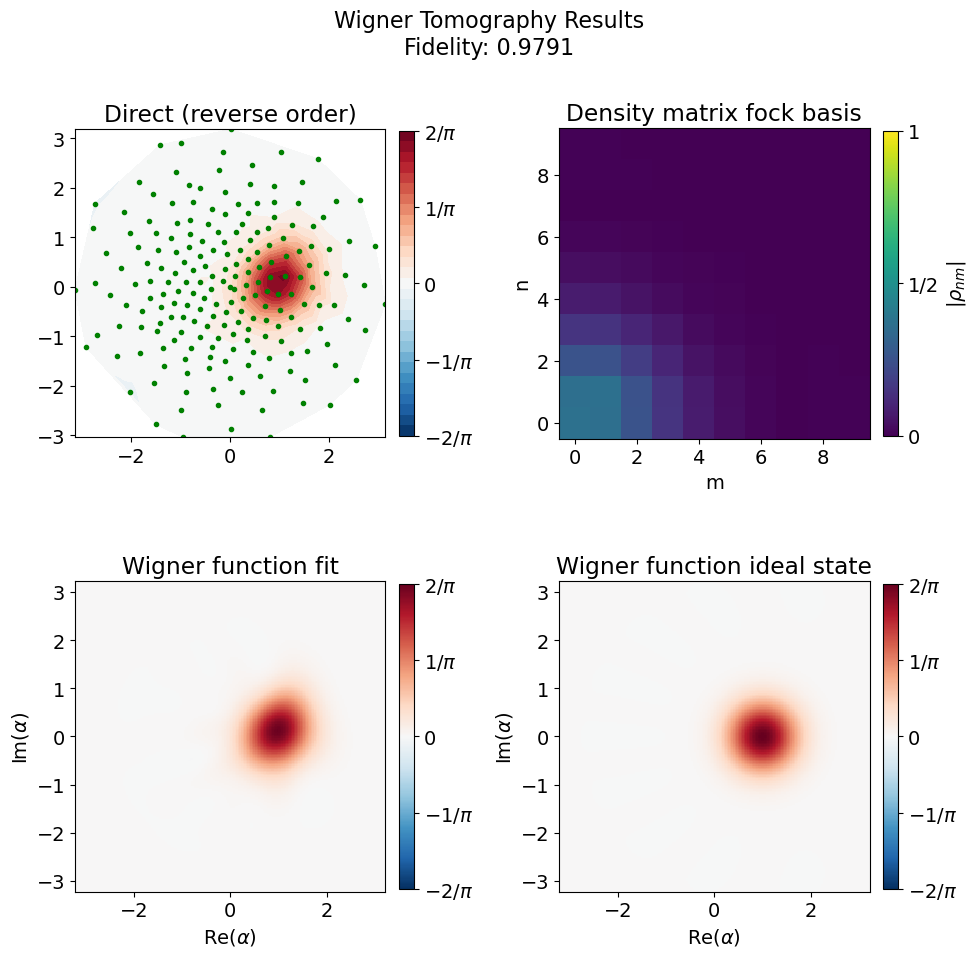

In [12]:
wigner_indv = wigner_list[0]
wigner_indv.cfg.expt.parity_post_select = True
avg_num = 5000
cutoff = 10
# ideal_state = (qt.basis(cutoff, 0)+qt.basis(cutoff, 4)).unit()
# ideal_state = (qt.basis(cutoff, 0)+qt.basis(cutoff, 1)).unit()
# ideal_state = (qt.basis(cutoff, 1)).unit()
ideal_state = (qt.coherent(cutoff, 1)).unit()
wigner_indv.analyze_wigner_temp(num_shots_sample = avg_num)
wigner_indv.display(rotate=True, 
                    initial_state=ideal_state, 
                    mode_state_num=cutoff, 
                    station=station, 
                    save_fig=False)

In [25]:
wigner_indv.cfg.device.manipulate.alpha_scale

[1.0, 1.0]

In [ ]:
from fitting.fitting import wigner_purity_calculation

cutoff = 10
i = 4
avg_nums = np.arange(100, 5001, 100)
purity_array_off = []
purity_array_on = []
for i in range(len(wigner_list)) :
    purity_list_off = []
    purity_list_on = []
    for avg_num in avg_nums:
        ideal_state = (qt.basis(cutoff, 0)+qt.basis(cutoff, 1)).unit()
        wigner_indv = wigner_list[i]
        wigner_indv.cfg.expt.parity_post_select = True
        wigner_indv.analyze_wigner_temp(num_shots_sample = avg_num)
        wigner_indv.display(rotate=True, 
                            initial_state=ideal_state, 
                            mode_state_num=cutoff, 
                            station=station, 
                            save_fig=False)
        purity_list_on.append(np.real(wigner_purity_calculation(wigner_indv, 
                                                                num_shots_sample = avg_num)[0]))
        wigner_indv.cfg.expt.parity_post_select = False
        wigner_indv.analyze_wigner_temp(num_shots_sample = avg_num)
        wigner_indv.display(rotate=True, 
                            initial_state=ideal_state, 
                            mode_state_num=cutoff, 
                            station=station, 
                            save_fig=False)
        purity_list_off.append(np.real(wigner_purity_calculation(wigner_indv, 
                                                                num_shots_sample = avg_num)[0]))
    purity_array_on.append(purity_list_on)
    purity_array_off.append(purity_list_off)


num shots start, end: 0 100
0 None
  parity post-select: keeping 17188/20100 shots (85.5%)
shape (201, 100)
max parity: 0.9474711605353604
max parity before scaling: 0.9474711605353604
Analyzing for wait_us_time=0, dummy=None
num shots start, end: 0 100
0 None
  parity post-select: keeping 17188/20100 shots (85.5%)
shape (201, 100)
max parity: 0.9474711605353604
max parity before scaling: 0.9474711605353604
Analyzing for wait_us_time=0, dummy=None
num shots start, end: 0 100
0 None
shape (201, 100)
max parity: 0.9041211101766192
max parity before scaling: 0.9041211101766192
Analyzing for wait_us_time=0, dummy=None
num shots start, end: 0 100
0 None
shape (201, 100)
max parity: 0.9041211101766192
max parity before scaling: 0.9041211101766192
Analyzing for wait_us_time=0, dummy=None
num shots start, end: 0 200
0 None
  parity post-select: keeping 34341/40200 shots (85.4%)
shape (201, 200)
max parity: 0.9590840010033497
max parity before scaling: 0.9590840010033497
Analyzing for wait_us_t

Text(0, 0.5, 'Purity')

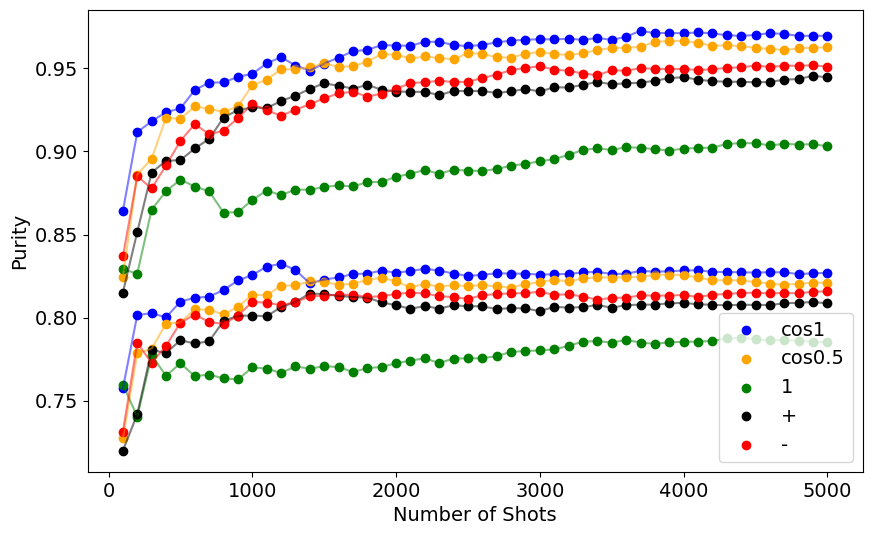

In [43]:
fig, ax = plt.subplots()
color_list = ["blue", "orange", "green", "black", "red"]
states = ['cos1', 'cos0.5', '1', '+', '-']
for i in range(len(purity_array_on)):
        purity_list_on = purity_array_on[i]
        purity_list_off = purity_array_off[i]
        ax.scatter(avg_nums, 
                purity_list_on,
                color = color_list[i],
                label = states[i])
        ax.plot(avg_nums, 
                purity_list_on,
                color = color_list[i],
                alpha = 0.5)
        ax.scatter(avg_nums,
                purity_list_off,
                color = color_list[i]),
                # label = "Post selection OFF")
        ax.plot(avg_nums, 
                purity_list_off,
                color = color_list[i],
                alpha = 0.5)
ax.legend()
ax.set_xlabel("Number of Shots")
ax.set_ylabel("Purity")